In [24]:
import pandas as pd

data_dir = "/Users/liuwenjin/Desktop/SmartEnumeration/PocketInformedSyntonSelection/ICMScreenReplacementGroups/Data/BenchMark-GPR91-6RNK"

# MEL-level: docking scores for top-1K 2-comp MEL fragments — used to establish MEL rank order for baseline
mel_frag_scores = pd.read_csv(f"{data_dir}/Top1K_2Comp_MEL_Frags_With_VS_OpenVS_Mapping.csv")

# Synthon-level: ICM Screen Replace scores per synthon merged with full ligand docking score (ground truth for simulation)
synthon_ground_truth = pd.read_csv(f"{data_dir}/all_mels_combined_core.csv")

# Inspect mel_frag_scores
print("=== MEL Fragment Docking Scores (ranking source) ===")
print(f"Shape: {mel_frag_scores.shape}")
print(f"Columns: {mel_frag_scores.columns.tolist()}")


# Inspect synthon_ground_truth
print("=== Synthon ICM Screen Replace + Full Ligand Docking (ground truth) ===")
print(f"Shape: {synthon_ground_truth.shape}")
print(f"Columns: {synthon_ground_truth.columns.tolist()}")
synthon_ground_truth.head(3)

# 1M random sample of 2-comp ligands docked to GPR91 with ICM 3.9.3 — used as a reference background distribution for EF calculations
random1M_docked = pd.read_csv(f"{data_dir}/GPR91_6RNK_Random1M_2CompLigands_ICM3.9.3_Docked.csv")


=== MEL Fragment Docking Scores (ranking source) ===
Shape: (1000, 48)
Columns: ['Nat', 'Nva', 'RTCNNscore', 'Score', 'dEel', 'dEgrid', 'dEhb', 'dEhp', 'dEin', 'dEsurf', 'dTSsc', 'mfScore', 'orig_index', 'occupied_slot', 'empty_slot', 'Mapped_Occupied_Synthon_Num', 'Name', 'source_csv', '__merge_key__', 'molid', 'molkey', 'full_synton_id', 'smiles_synthon_s1', 'smiles_synthon_s2', 'smiles_synthon_s3', 'MW', 'Tox_Class', 'Tox_Names', 'Tox_Score', 'molPAINS', 'icm_rdmol_binary', 'icm_inchikey', 'icm_inchikey_block1', 'badGroups', 'subcase', 'occupied_synthon_InChiKey', 'associated_rxn_id', 'openvs_full_synton_id_list', 'all_matched_ids', 'openvs_synthon_source_file', 'openvs_full_synthon_id', 'openvs_mel_productinchi', 'openvs_rdmol_binary', 'openvs_rdmol_inchikey', 'openvs_inchikey_block1', 'connectivity_match', 'source_file', 'mel_synthon_inchikey']
=== Synthon ICM Screen Replace + Full Ligand Docking (ground truth) ===
Shape: (10046534, 14)
Columns: ['mel_inchikey', 'source_dir', 'Sub

,mel_inchikey,source_dir,SubstScore,RTCNN_Score,DockScore,Strain,CoreRmsd,MolLogP,MolLogS,MoldHf,MolPSA,MolVolume,FullLigand_Score,FullLigand_RTCNNscore
0,ACFDHRGCMPAHBH_BXLOPNDQSA_N,ICMInChikey_ACFDHRGCMPAHBH_BXLOPNDQSA_N_OpenVS...,329.150,188.954,2202781.791,2202781.791,18.394,5.067,-6.091,-34.885,77.214,352.849,-23.783,-36.716
1,ACFDHRGCMPAHBH_BXLOPNDQSA_N,ICMInChikey_ACFDHRGCMPAHBH_BXLOPNDQSA_N_OpenVS...,376.299,184.154,6879.603,6879.603,13.994,5.516,-6.947,-61.782,90.956,430.075,-16.064,-41.925
2,ACFDHRGCMPAHBH_BXLOPNDQSA_N,ICMInChikey_ACFDHRGCMPAHBH_BXLOPNDQSA_N_OpenVS...,367.744,174.466,13312.322,13312.322,12.488,3.252,-4.039,-10.131,99.139,364.170,NaN,NaN


In [61]:

synthon_ground_truth['mel_inchikey'].nunique()


,Name,Nat,Nva,RTCNNscore,Score,dEel,dEgrid,dEhb,dEhp,dEin,dEsurf,dTSsc,mfScore,source_csv
0,C11H10C,28.000,3.000,-22.650,-17.663,9.096,-26.437,-2.678,-6.480,4.933,12.169,1.624,-74.899,dock_6rnk_new_rnd_single_2comp_REAL2023_0_0251...
1,C17H11FN4O,34.000,2.000,-35.878,-16.271,15.089,-33.988,0.000,-5.754,5.265,9.672,1.276,-59.380,dock_6rnk_new_rnd_single_2comp_REAL2023_0_0251...
2,C18H14B,39.000,4.000,-32.465,-10.635,17.708,-35.259,0.000,-5.958,6.757,13.965,1.746,-94.894,dock_6rnk_new_rnd_single_2comp_REAL2023_0_0251...
3,C16H15B,36.000,3.000,-31.706,-6.417,17.507,-28.130,-0.071,-7.178,5.542,13.363,1.812,-117.802,dock_6rnk_new_rnd_single_2comp_REAL2023_0_0251...
4,C23H18N4O2S2,49.000,4.000,-30.729,-16.045,18.107,-37.227,-3.199,-6.595,7.569,19.734,2.272,-83.948,dock_6rnk_new_rnd_single_2comp_REAL2023_0_0251...


In [55]:
synthon_ground_truth['FullLigand_Score'].describe()

count   8427889.000
mean        -16.160
std           6.939
min         -55.197
25%         -20.760
50%         -16.009
75%         -11.344
max           6.891
Name: FullLigand_Score, dtype: float64

#### V-SYNTHES Baseline - First1M FullEnumerated Ligand From Top Ranked MEL Frags

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

BUDGET = 1_000_000

# Normalize InChIKey separator: underscore → dash
mel_frag_scores['key_norm'] = mel_frag_scores['icm_inchikey'].str.replace('_', '-')
synthon_ground_truth['key_norm'] = synthon_ground_truth['mel_inchikey'].str.replace('_', '-')

# Rank MELs by ICM docking score (lower/more negative = better)
mel_ranked = mel_frag_scores.sort_values('Score', ascending=True).reset_index(drop=True)
mel_ranked['mel_rank'] = mel_ranked.index + 1

# Count available synthons per MEL in ground truth
synthon_counts = synthon_ground_truth.groupby('key_norm').size().rename('n_synthons')
available_keys = set(synthon_counts.index)

mel_ranked['has_docking'] = mel_ranked['key_norm'].isin(available_keys)

# Baseline walk: go rank 1 → N, include all synthons per MEL until budget hit
cumulative = 0
baseline_records = []

for _, row in mel_ranked.iterrows():
    key = row['key_norm']
    if not row['has_docking']:
        continue
    n = synthon_counts[key]
    cumulative += n
    baseline_records.append({
        'mel_rank': row['mel_rank'],
        'key_norm': key,
        'Score': row['Score'],
        'n_synthons': n,
        'cumulative': cumulative
    })
    if cumulative >= BUDGET:
        break

baseline_df = pd.DataFrame(baseline_records)

# Summary: rank coverage and skipped MELs
rank_min, rank_max = baseline_df['mel_rank'].min(), baseline_df['mel_rank'].max()
n_included = len(baseline_df)
total_ligands = baseline_df['cumulative'].iloc[-1]

print(f"=== Baseline Coverage ===")
print(f"MEL rank range covered : {rank_min} – {rank_max}")
print(f"MELs with docking included : {n_included}")
print(f"Total ligands in baseline  : {total_ligands:,}  (budget = {BUDGET:,})")
print()

# MELs skipped within the covered rank range (docking not finished)
skipped_in_range = mel_ranked[
    (mel_ranked['mel_rank'] <= rank_max) & (~mel_ranked['has_docking'])
]
print(f"=== Skipped MELs (no docking data, within rank 1–{rank_max}) ===")
print(f"Count: {len(skipped_in_range)}")
print(skipped_in_range[['mel_rank', 'Score', 'key_norm']].to_string(index=False))
print()



=== Baseline Coverage ===
MEL rank range covered : 1 – 135
MELs with docking included : 78
Total ligands in baseline  : 1,001,617  (budget = 1,000,000)

=== Skipped MELs (no docking data, within rank 1–135) ===
Count: 57
 mel_rank   Score                    key_norm
        4 -38.168 FXYKQHKHWKAUPR-JDEQIACOSA-N
        5 -37.900 ZIMWFZVTSODHOP-HEQDSYSVSA-N
        9 -37.462 VXUIVXWGSBEJED-JRARVOFBSA-N
       10 -37.304 JABZDZBXNLXFNW-MYGVBPACSA-N
       13 -36.559 QAXKDNZVYCXSHR-FDAFSMDASA-N
       14 -36.410 VULVNTLPWUGUPK-YTDXTPLISA-N
       15 -36.238 FBNCBXUVXBDJLL-GQCMPPMQSA-N
       18 -36.056 BBEKLQCQWXCELR-DFTKRCFWSA-N
       19 -36.052 ZXATWQFPFTWPAS-GWJFINNXSA-N
       20 -36.039 IOSXXOJNTVITMV-AFUUIUSJSA-N
       21 -35.980 XVICQXRPJXDYRX-QCLINTAOSA-N
       22 -35.976 YPXIXYWIHSFRJA-XLHVAGFGSA-N
       25 -35.762 JVCGGDXOZXBAKF-LQPWBTTBSA-N
       26 -35.760 JTYKDFHGABSNKO-LPENSUDTSA-N
       29 -35.595 TUJHQIZKVFABMD-JCLIXISWSA-N
       31 -35.471 GHYIEIGGSMIVIO-LPENSUDTSA

=== Baseline Ligand FullLigand_Score Distribution ===
count   974233.000
mean       -17.742
std          7.589
min        -55.197
25%        -22.772
50%        -17.236
75%        -12.432
max          6.891
Name: FullLigand_Score, dtype: float64



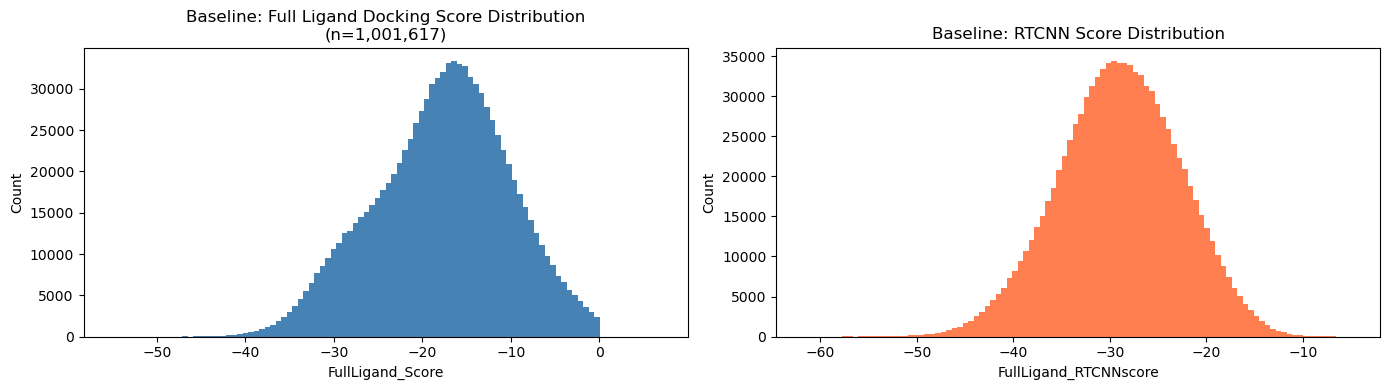

In [ ]:
# Pull ground truth scores for all baseline ligands
baseline_keys = set(baseline_df['key_norm'])
baseline_ligands = synthon_ground_truth[synthon_ground_truth['key_norm'].isin(baseline_keys)].copy()

# Score distribution
print(f"=== Baseline Ligand FullLigand_Score Distribution ===")
print(baseline_ligands['FullLigand_Score'].describe())
print()

# Plot score histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(baseline_ligands['FullLigand_Score'].dropna(), bins=100, color='steelblue', edgecolor='none')
axes[0].set_xlabel('FullLigand_Score')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Baseline: Full Ligand Docking Score Distribution\n(n={len(baseline_ligands):,})')

axes[1].hist(baseline_ligands['FullLigand_RTCNNscore'].dropna(), bins=100, color='coral', edgecolor='none')
axes[1].set_xlabel('FullLigand_RTCNNscore')
axes[1].set_ylabel('Count')
axes[1].set_title('Baseline: RTCNN Score Distribution')

plt.tight_layout()
plt.show()


=== Synthon Counts Across All Available MELs (507 MELs) ===
count     507.000
mean    19815.649
std     14536.041
min        13.000
25%      6278.500
50%     19960.000
75%     32086.500
max     49648.000
Name: n_synthons, dtype: float64

Median synthons per MEL : 19,960
Mean   synthons per MEL : 19,816

=== Baseline MELs: synthons per MEL (rank order) ===
 mel_rank   Score  n_synthons  cumulative
        1 -42.213          15          15
        2 -40.825          15          30
        3 -38.456       40683       40713
        6 -37.880          61       40774
        7 -37.659         391       41165
        8 -37.614          63       41228
       11 -37.204       26881       68109
       12 -36.622        6172       74281
       16 -36.146       29306      103587
       17 -36.057       39323      142910
       23 -35.905         843      143753
       24 -35.794          63      143816
       27 -35.623       13971      157787
       28 -35.620          50      157837
       30 -3

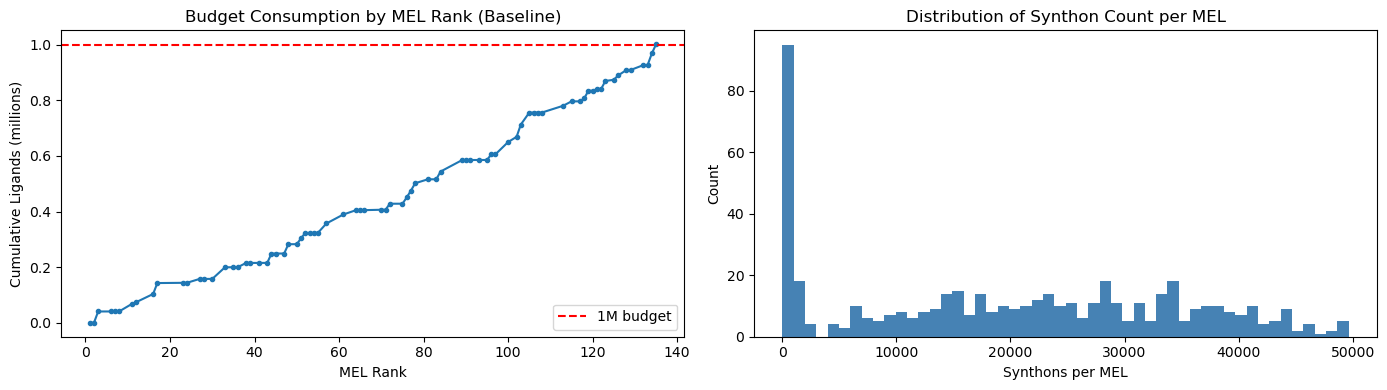

In [ ]:
# Synthons per MEL — understand why 1M fills so fast
synthon_count_df = synthon_counts.reset_index()
synthon_count_df.columns = ['key_norm', 'n_synthons']

print(f"=== Synthon Counts Across All Available MELs ({len(synthon_count_df)} MELs) ===")
print(synthon_count_df['n_synthons'].describe())
print()
print(f"Median synthons per MEL : {synthon_count_df['n_synthons'].median():,.0f}")
print(f"Mean   synthons per MEL : {synthon_count_df['n_synthons'].mean():,.0f}")
print()

# Show per-MEL counts for the 78 that made it into baseline
baseline_df_annotated = baseline_df.copy()
print(f"=== Baseline MELs: synthons per MEL (rank order) ===")
print(baseline_df_annotated[['mel_rank', 'Score', 'n_synthons', 'cumulative']].to_string(index=False))

# Cumulative budget curve
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(baseline_df['mel_rank'], baseline_df['cumulative'] / 1e6, marker='o', markersize=3)
axes[0].axhline(1.0, color='red', linestyle='--', label='1M budget')
axes[0].set_xlabel('MEL Rank')
axes[0].set_ylabel('Cumulative Ligands (millions)')
axes[0].set_title('Budget Consumption by MEL Rank (Baseline)')
axes[0].legend()

axes[1].hist(synthon_count_df['n_synthons'], bins=50, color='steelblue', edgecolor='none')
axes[1].set_xlabel('Synthons per MEL')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Synthon Count per MEL')

plt.tight_layout()
plt.show()


=== MEL Dominance (sorted by synthon contribution) ===
 mel_rank   Score  n_synthons  pct_of_budget  cumulative_pct
      103 -33.092       44206          4.413           4.413
      100 -33.171       44200          4.413           8.826
      105 -33.084       42994          4.292          13.119
       33 -35.358       41817          4.175          17.294
      134 -32.655       41616          4.155          21.449
        3 -38.456       40683          4.062          25.510
       89 -33.432       40403          4.034          29.544
       17 -36.057       39323          3.926          33.470
       44 -34.893       33568          3.351          36.821
       48 -34.627       33496          3.344          40.166
       57 -34.195       33494          3.344          43.510
      135 -32.636       32910          3.286          46.795
       61 -34.099       32280          3.223          50.018
       16 -36.146       29306          2.926          52.944
      123 -32.785       28608 

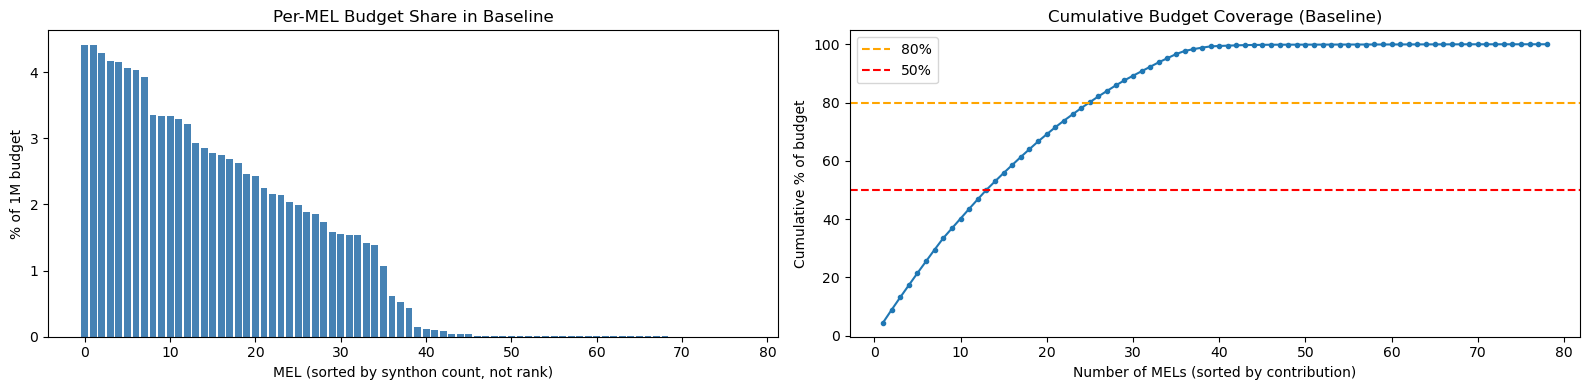

In [ ]:
# Pareto analysis: which MELs dominate the 1M baseline budget
baseline_df_sorted = baseline_df.sort_values('n_synthons', ascending=False).copy()
baseline_df_sorted['pct_of_budget'] = baseline_df_sorted['n_synthons'] / total_ligands * 100
baseline_df_sorted['cumulative_pct'] = baseline_df_sorted['pct_of_budget'].cumsum()

print("=== MEL Dominance (sorted by synthon contribution) ===")
print(baseline_df_sorted[['mel_rank', 'Score', 'n_synthons', 'pct_of_budget', 'cumulative_pct']].to_string(index=False))
print()

# How many MELs cover 50% / 80% / 90% of the budget
for threshold in [50, 80, 90]:
    n = (baseline_df_sorted['cumulative_pct'] <= threshold).sum() + 1
    print(f"Top {n} MELs cover {threshold}% of the 1M budget")

# Bar chart: each MEL's share, sorted by contribution
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].bar(range(len(baseline_df_sorted)), baseline_df_sorted['pct_of_budget'], color='steelblue')
axes[0].set_xlabel('MEL (sorted by synthon count, not rank)')
axes[0].set_ylabel('% of 1M budget')
axes[0].set_title('Per-MEL Budget Share in Baseline')

# Lorenz-style cumulative curve
axes[1].plot(range(1, len(baseline_df_sorted)+1), baseline_df_sorted['cumulative_pct'], marker='o', markersize=3)
axes[1].axhline(80, color='orange', linestyle='--', label='80%')
axes[1].axhline(50, color='red', linestyle='--', label='50%')
axes[1].set_xlabel('Number of MELs (sorted by contribution)')
axes[1].set_ylabel('Cumulative % of budget')
axes[1].set_title('Cumulative Budget Coverage (Baseline)')
axes[1].legend()

plt.tight_layout()
plt.show()


#### ICM ScreenReplace PocketInformed Synton Selection

##### Strategy A — Global Hard Synton RTCNN Score Cutoff (Pre-Filter, Then Walk MELs)
Core idea:
Apply a single global quality gate across all synthons from all MELs before any enumeration happens. Only synthons that survive the filter are eligible. Then walk MELs in docking-rank order and take every eligible synthon until 1M is reached.

Step-by-step:
Compute a global score threshold S_min across all synthons from all MELs.
GLOBAL_TOP = 0.20 → keep the globally top-20% best-scoring synthons.
S_min = _score.quantile(GLOBAL_TOP) → any synthon with _score ≤ S_min passes the gate.
(Because ICM scores are negative, more negative = better. The 20th percentile value is a relatively negative number — only the sharpest 20% globally survive.)
Filter the entire synthon pool — discard every synthon with _score > S_min. This step is global and runs once before any MEL traversal. MELs with uniformly poor synthons lose most of their synthons; MELs with uniformly good synthons lose very few.
Walk MELs in docking-rank order (best MEL → worst MEL). For each MEL, take all of its surviving synthons as a flat set — no further ranking within the MEL. Move to the next MEL. Stop when the global total hits 1M.

How it differs from the Baseline:
MEL traversal order is identical (best MEL first).
Each MEL contributes fewer synthons (only the ones that passed the global filter), so the 1M budget is consumed more slowly → you go deeper into the MEL ranked list before hitting 1M.
Every compound in the final 1M passed a global quality screen — no junk synthons included.

What it does NOT do:
Does not rank or prioritize synthons within a MEL — survivors are taken as a flat, unordered set.
Does not reorder MELs — a poor MEL that happens to have a few great synthons still gets visited late.
Key parameter: GLOBAL_TOP (fraction of the global synthon pool to keep)
Current setting: GLOBAL_TOP = 0.20 (top 20% globally)

Scoring signal used (Options 1–6 control what _score is):
Option 1: _score = RTCNN_Score only
Option 2: hard filters (Strain > 15 or CoreRMSD > 2.0 Å → exclude), then _score = RTCNN_Score
Option 3: _score = mean(norm(Strain), norm(RTCNN_Score)) — no hard filters
Option 4: same combined score as Option 3, but hard filters applied first
Option 5: _score = mean(norm(Strain), norm(CoreRMSD), norm(RTCNN_Score)) — no hard filters
Option 6: same combined score as Option 5, but hard filters applied first

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BUDGET     = 1_000_000
GLOBAL_TOP = 0.20   # keep globally top-20% best synthons (lowest _score)

strategy_labels_a = {
    1: "RTCNN cutoff only",
    2: "Hard filters + RTCNN cutoff",
    3: "Strain+RTCNN combined cutoff",
    4: "Hard filters + Strain+RTCNN combined cutoff",
    5: "Strain+RMSD+RTCNN combined cutoff",
    6: "Hard filters + Strain+RMSD+RTCNN combined cutoff",
}

thresholds = np.linspace(-50, -30, 200)

def compute_ef_vs_baseline(selected_df, baseline_df, thresholds):
    n_sel  = len(selected_df)
    n_base = len(baseline_df)
    ef = []
    for t in thresholds:
        r_sel  = (selected_df["FullLigand_Score"] <= t).sum() / n_sel  if n_sel  > 0 else 0
        r_base = (baseline_df["FullLigand_Score"] <= t).sum() / n_base if n_base > 0 else 0
        ef.append(r_sel / r_base if r_base > 0 else np.nan)
    return np.array(ef)

# ── helpers ────────────────────────────────────────────────────────────────

def hard_filter(df):
    return df[(df["Strain"] <= 15) & (df["CoreRmsd"] <= 2.0)].copy()

def global_minmax_combined(df, cols):
    d = df.copy()
    for c in cols:
        mn, mx = d[c].min(), d[c].max()
        d[f"_n_{c}"] = (d[c] - mn) / (mx - mn + 1e-9)
    d["_score"] = d[[f"_n_{c}" for c in cols]].mean(axis=1)
    return d

def build_pool_a(synthon_df, strategy, top_frac):
    """Global hard cutoff: keep only synthons in the best top_frac globally."""
    df = hard_filter(synthon_df) if strategy in (2, 4, 6) else synthon_df.copy()
    if strategy in (1, 2):
        df["_score"] = df["RTCNN_Score"]
    elif strategy in (3, 4):
        df = global_minmax_combined(df, ["Strain", "RTCNN_Score"])
    else:
        df = global_minmax_combined(df, ["Strain", "CoreRmsd", "RTCNN_Score"])
    S_min = df["_score"].quantile(top_frac)
    pool  = df[df["_score"] <= S_min].copy()
    return pool, S_min

def walk_mel_budget(pool, mel_ranked, budget):
    """Walk MELs in docking-rank order; take all survivors per MEL until budget."""
    pool_counts  = pool.groupby("key_norm").size()
    keys_in_pool = set(pool_counts.index)
    cumulative, selected_keys = 0, []
    rank_min = rank_max = None
    for _, row in mel_ranked.iterrows():
        key = row["key_norm"]
        if key not in keys_in_pool:
            continue
        cumulative += pool_counts[key]
        selected_keys.append(key)
        if rank_min is None:
            rank_min = row["mel_rank"]
        rank_max = row["mel_rank"]
        if cumulative >= budget:
            break
    selected = pool[pool["key_norm"].isin(set(selected_keys))]
    return selected, len(selected_keys), len(selected), rank_min, rank_max

# ── sanity check ───────────────────────────────────────────────────────────

p20_rtcnn = synthon_ground_truth["RTCNN_Score"].quantile(0.20)
print("=== Sign-convention check ===")
print(f"RTCNN_Score 20th pct : {p20_rtcnn:.3f}  (threshold for top-20% globally)")
print(f"More negative = better  →  keep RTCNN_Score ≤ {p20_rtcnn:.3f}\n")
print(f"Baseline (VS) : {len(baseline_df)} MELs, "
      f"rank {baseline_df['mel_rank'].min()}–{baseline_df['mel_rank'].max()}, "
      f"{len(baseline_ligands):,} ligands\n")

# ── run all 6 strategies ──────────────────────────────────────────────────

results_a = {}

for s in range(1, 7):
    pool, S_min = build_pool_a(synthon_ground_truth, s, GLOBAL_TOP)
    sel, n_mels, n_ligs, r_min, r_max = walk_mel_budget(pool, mel_ranked, BUDGET)
    results_a[s] = dict(
        selected  = sel,
        n_mels    = n_mels,
        n_ligands = n_ligs,
        rank_min  = r_min,
        rank_max  = r_max,
        S_min     = S_min,
        ef        = compute_ef_vs_baseline(sel, baseline_ligands, thresholds),
    )
    print(f"S{s}  [{strategy_labels_a[s]}]")
    print(f"     S_min = {S_min:.4f} | {n_mels} MELs | "
          f"rank {r_min}–{r_max} | {n_ligs:,} ligands\n")


=== Sign-convention check ===
RTCNN_Score 20th pct : -27.840  (threshold for top-20% globally)
More negative = better  →  keep RTCNN_Score ≤ -27.840

Baseline (VS) : 78 MELs, rank 1–135, 1,001,617 ligands

S1  [RTCNN cutoff only]
     S_min = -27.8403 | 287 MELs | rank 1–478 | 1,001,913 ligands

S2  [Hard filters + RTCNN cutoff]
     S_min = -28.3318 | 322 MELs | rank 1–539 | 1,007,697 ligands

S3  [Strain+RTCNN combined cutoff]
     S_min = 0.0754 | 287 MELs | rank 1–478 | 1,001,913 ligands

S4  [Hard filters + Strain+RTCNN combined cutoff]
     S_min = 0.5132 | 319 MELs | rank 1–532 | 1,003,746 ligands

S5  [Strain+RMSD+RTCNN combined cutoff]
     S_min = 0.0470 | 285 MELs | rank 1–478 | 1,001,390 ligands

S6  [Hard filters + Strain+RMSD+RTCNN combined cutoff]
     S_min = 0.4081 | 307 MELs | rank 1–522 | 1,002,967 ligands



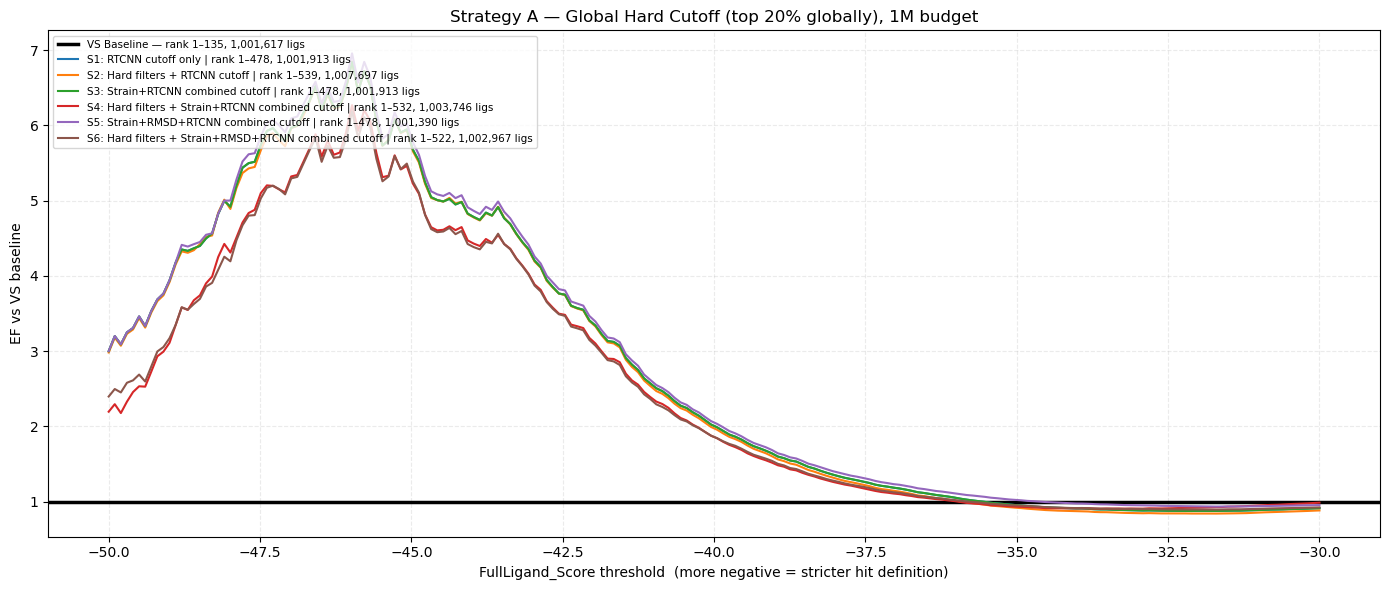

In [32]:
# ── Strategy A — EF curves vs VS baseline ─────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 6))

ax.axhline(1.0, color="k", linewidth=2.5,
           label=f"VS Baseline — rank 1–{baseline_df['mel_rank'].max()}, "
                 f"{len(baseline_ligands):,} ligs")

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]

for s, c in zip(range(1, 7), colors):
    r = results_a[s]
    ax.plot(thresholds, r["ef"], color=c,
            label=f"S{s}: {strategy_labels_a[s]} | "
                  f"rank 1–{r['rank_max']}, {r['n_ligands']:,} ligs")

ax.set_xlabel("FullLigand_Score threshold  (more negative = stricter hit definition)")
ax.set_ylabel("EF vs VS baseline")
ax.set_title(f"Strategy A — Global Hard Cutoff (top {int(GLOBAL_TOP*100)}% globally), 1M budget")
ax.legend(fontsize=7.5, loc="upper left")
ax.grid(alpha=0.25, linestyle="--")
plt.tight_layout()
plt.show()


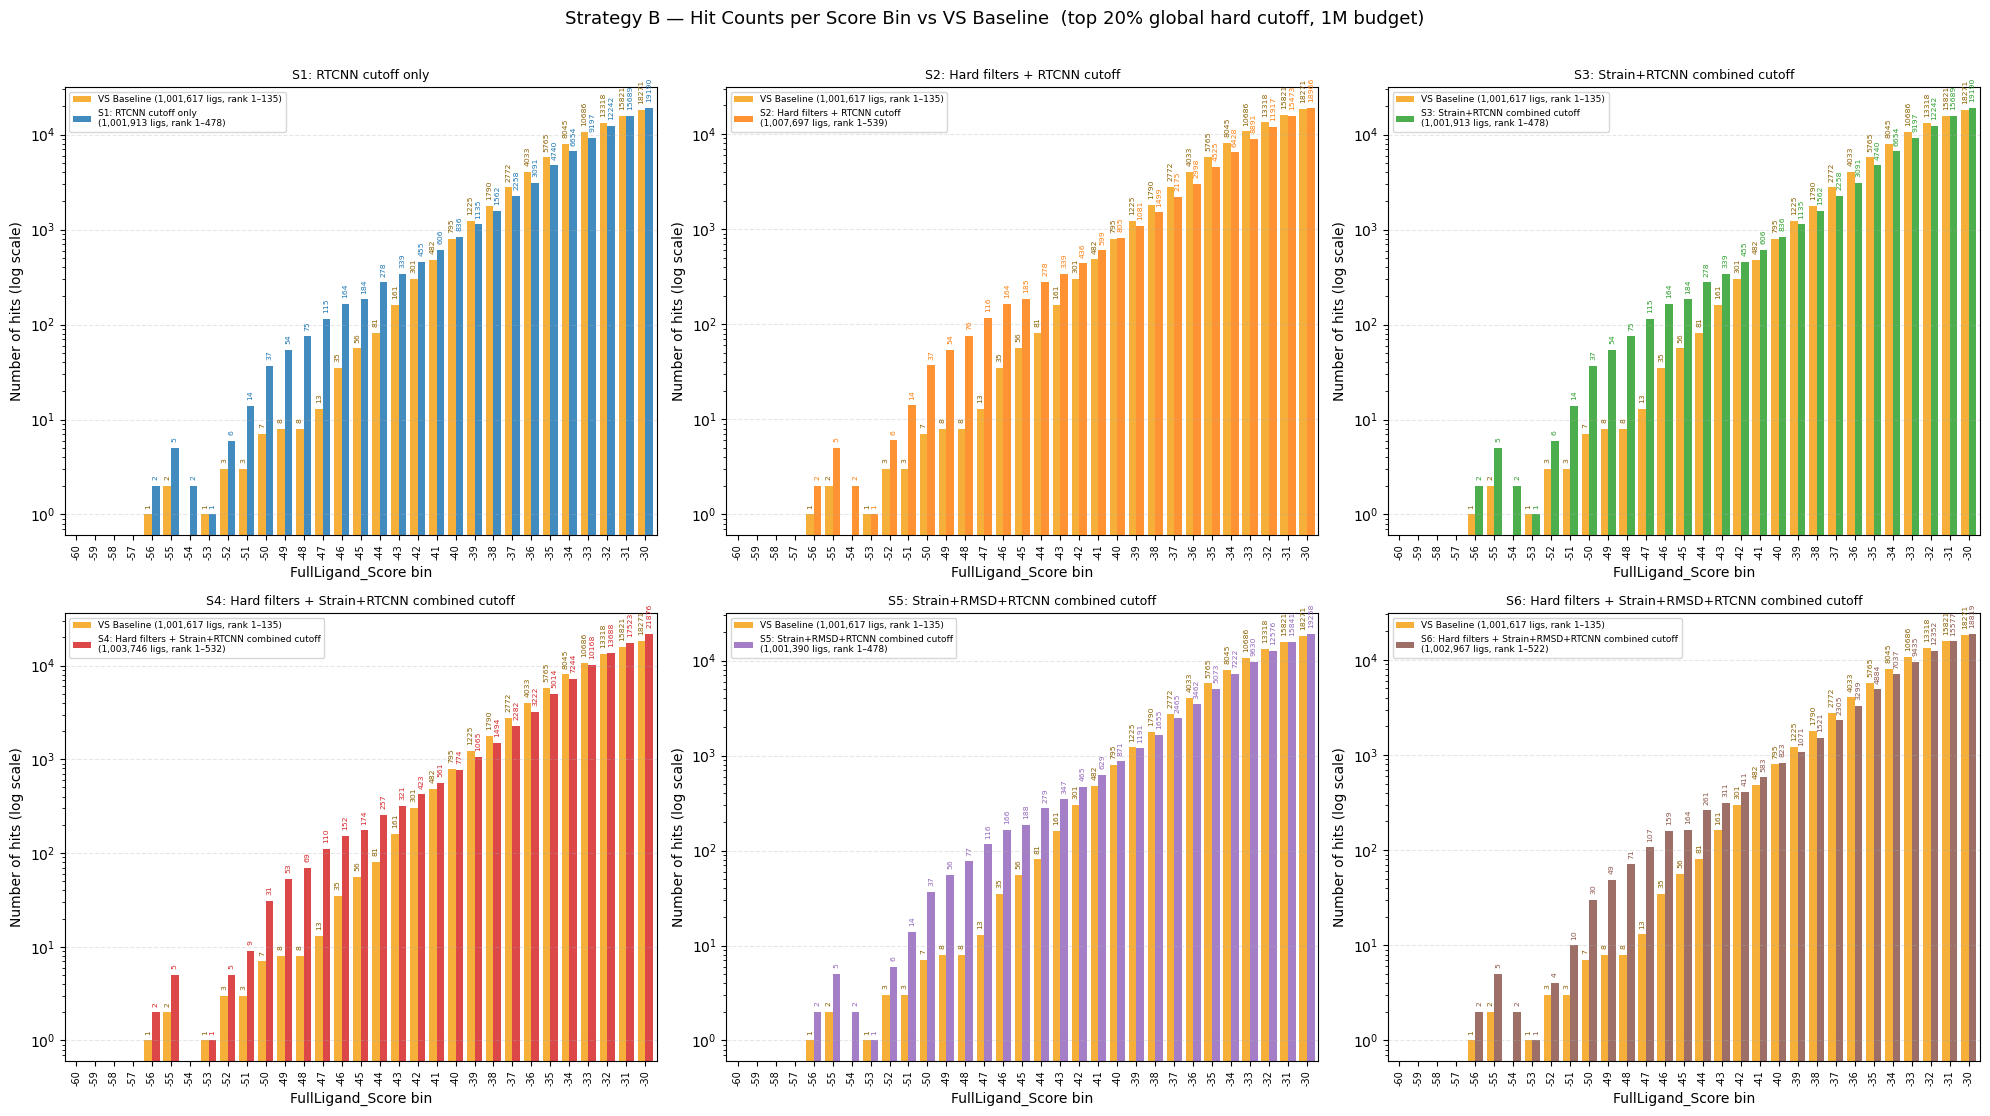

In [33]:
# ── Strategy B — Hit-count histograms per score bin ───────────────────────

score_bins = np.arange(-60, -29, 1)

def count_per_bin(df, bins):
    return np.array(
        [((df["FullLigand_Score"] >= b) & (df["FullLigand_Score"] < b + 1)).sum()
         for b in bins],
        dtype=float,
    )

baseline_counts_b = count_per_bin(baseline_ligands, score_bins)

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

strat_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]
x     = np.arange(len(score_bins))
width = 0.4

for idx, s in enumerate(range(1, 7)):
    ax           = axes[idx]
    sel          = results_a[s]["selected"]
    strat_counts = count_per_bin(sel, score_bins)

    base_plot  = np.where(baseline_counts_b == 0, np.nan, baseline_counts_b)
    strat_plot = np.where(strat_counts      == 0, np.nan, strat_counts)

    bars_base  = ax.bar(
        x - width / 2, base_plot, width, color="#F5A623", alpha=0.9,
        label=f"VS Baseline ({len(baseline_ligands):,} ligs, rank 1–{baseline_df['mel_rank'].max()})",
    )
    bars_strat = ax.bar(
        x + width / 2, strat_plot, width, color=strat_colors[idx], alpha=0.85,
        label=f"S{s}: {strategy_labels_a[s]}\n"
              f"({results_a[s]['n_ligands']:,} ligs, rank 1–{results_a[s]['rank_max']})",
    )

    for bar, count in zip(bars_base, baseline_counts_b):
        if count > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, count * 1.15,
                    str(int(count)), ha="center", va="bottom",
                    fontsize=5.5, color="#8B6000", rotation=90)

    for bar, count in zip(bars_strat, strat_counts):
        if count > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, count * 1.15,
                    str(int(count)), ha="center", va="bottom",
                    fontsize=5.5, color=strat_colors[idx], rotation=90)

    ax.set_yscale("log")
    ax.set_xticks(x)
    ax.set_xticklabels([str(b) for b in score_bins], rotation=90, fontsize=7)
    ax.set_xlabel("FullLigand_Score bin")
    ax.set_ylabel("Number of hits (log scale)")
    ax.set_title(f"S{s}: {strategy_labels_a[s]}", fontsize=9)
    ax.legend(fontsize=6.5, loc="upper left")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.set_xlim(-0.6, len(score_bins) - 0.4)

plt.suptitle(
    f"Strategy B — Hit Counts per Score Bin vs VS Baseline  "
    f"(top {int(GLOBAL_TOP*100)}% global hard cutoff, 1M budget)",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()


##### Strategy B — Greedy Top-X% Synton (RTCNN-Based) Per MEL (Local Fraction Cutoff, Then Walk MELs)
Core idea: Each MEL gets its own local cutoff — always keep the best X% of that MEL's synthons, ranked by score, regardless of how good or bad that MEL's synthons are in absolute terms. Then walk MELs in docking-rank order, taking those top-X% synthons from each MEL until 1M is reached.

Step-by-step:
Walk MELs in docking-rank order (best MEL → worst MEL).
For each MEL, rank its synthons by RTCNNScore best to worst (most negative first, since lower = better).
Take only the top FRACTION of that MEL's synthons:
n_take = ceil(n_synthons_in_MEL × FRACTION) (at least 1, capped by remaining budget).
(Example: a MEL with 10,000 synthons at FRACTION = 0.10 contributes its best 1,000.)
Move to the next MEL. Stop when the global total hits 1M.

How it differs from the Baseline:
MEL traversal order is identical (best MEL first).
Each MEL contributes only its top-X% synthons (ranked, not flat), so the 1M budget is consumed more slowly → you reach deeper into the MEL ranked list.
Within each MEL, synthons are ranked and only the best fraction is taken — unlike the Baseline which takes all synthons from each MEL with no quality filter.

What it does NOT do:
Does not apply a global score floor — if a MEL has poor synthons, Strategy B still takes its top X% of them regardless of their absolute score.
Does not reorder MELs

Key parameter: FRACTION (fraction of each MEL's synthons to keep)
Current setting: FRACTION = 0.10 (top 10% per MEL)

Scoring signal used (Options 1–6 control what _score is):
Option 1: _score = RTCNN_Score only
Option 2: hard filters (Strain > 15 or CoreRMSD > 2.0 Å → exclude), then _score = RTCNN_Score
Option 3: _score = mean(norm(Strain), norm(RTCNN_Score)) — no hard filters
Option 4: same combined score as Option 3, but hard filters applied first
Option 5: _score = mean(norm(Strain), norm(CoreRMSD), norm(RTCNN_Score)) — no hard filters
Option 6: same combined score as Option 5, but hard filters applied first

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BUDGET   = 1_000_000
FRACTION = 0.20   # top 20% of each MEL's synthons (per-MEL local cutoff)

strategy_labels_b = {
    1: "RTCNN only",
    2: "Hard filters + RTCNN",
    3: "Strain+RTCNN combined",
    4: "Hard filters + Strain+RTCNN combined",
    5: "Strain+RMSD+RTCNN combined",
    6: "Hard filters + Strain+RMSD+RTCNN combined",
}

thresholds = np.linspace(-50, -30, 200)

def compute_ef_vs_baseline(selected_df, baseline_df, thresholds):
    n_sel  = len(selected_df)
    n_base = len(baseline_df)
    ef = []
    for t in thresholds:
        r_sel  = (selected_df["FullLigand_Score"] <= t).sum() / n_sel  if n_sel  > 0 else 0
        r_base = (baseline_df["FullLigand_Score"] <= t).sum() / n_base if n_base > 0 else 0
        ef.append(r_sel / r_base if r_base > 0 else np.nan)
    return np.array(ef)

# ── helpers ────────────────────────────────────────────────────────────────

def hard_filter(df):
    return df[(df["Strain"] <= 15) & (df["CoreRmsd"] <= 2.0)].copy()

def global_minmax_combined(df, cols):
    d = df.copy()
    for c in cols:
        mn, mx = d[c].min(), d[c].max()
        d[f"_n_{c}"] = (d[c] - mn) / (mx - mn + 1e-9)
    d["_score"] = d[[f"_n_{c}" for c in cols]].mean(axis=1)
    return d

def prepare_scored_pool_b(synthon_df, strategy):
    df = hard_filter(synthon_df) if strategy in (2, 4, 6) else synthon_df.copy()
    if strategy in (1, 2):
        df["_score"] = df["RTCNN_Score"]
    elif strategy in (3, 4):
        df = global_minmax_combined(df, ["Strain", "RTCNN_Score"])
    else:
        df = global_minmax_combined(df, ["Strain", "CoreRmsd", "RTCNN_Score"])
    return df

def run_strategy_b(scored_df, mel_ranked, fraction, budget):
    """
    Greedy TopX% per MEL:
    Walk MELs in docking-rank order. For each MEL, take the top `fraction`
    of that MEL's synthons by _score (local cutoff, not global).
    Stop when global total hits budget.
    """
    mel_groups     = {k: g for k, g in scored_df.groupby("key_norm")}
    available_keys = set(mel_groups.keys())

    selected_parts = []
    cumulative = 0
    n_mels     = 0
    rank_min   = rank_max = None

    for _, row in mel_ranked.iterrows():
        if cumulative >= budget:
            break
        key = row["key_norm"]
        if key not in available_keys:
            continue

        mel_df  = mel_groups[key]
        n_total = len(mel_df)
        n_take  = max(1, int(np.ceil(n_total * fraction)))   # at least 1
        n_take  = min(n_take, budget - cumulative)            # don't exceed budget

        top_synthons = mel_df.nsmallest(n_take, "_score")
        selected_parts.append(top_synthons)
        cumulative += len(top_synthons)
        n_mels += 1

        if rank_min is None:
            rank_min = row["mel_rank"]
        rank_max = row["mel_rank"]

    selected = pd.concat(selected_parts, ignore_index=True) if selected_parts else pd.DataFrame()
    return selected, n_mels, len(selected), rank_min, rank_max

# ── pre-score pools once per strategy ─────────────────────────────────────
print("=== Preparing scored pools ===")
scored_cache_b = {}
for s in range(1, 7):
    scored_cache_b[s] = prepare_scored_pool_b(synthon_ground_truth, s)
    print(f"S{s} [{strategy_labels_b[s]}]: {len(scored_cache_b[s]):,} synthons in pool")
print()

# ── run all 6 strategies ──────────────────────────────────────────────────
print("=== Running Strategy B (Greedy Top-X% per MEL) ===")
print(f"Fraction per MEL : {FRACTION:.0%}")
print(f"Baseline (VS)    : {len(baseline_df)} MELs, "
      f"rank {baseline_df['mel_rank'].min()}–{baseline_df['mel_rank'].max()}, "
      f"{len(baseline_ligands):,} ligands\n")

results_b = {}
for s in range(1, 7):
    sel, n_mels, n_ligs, r_min, r_max = run_strategy_b(
        scored_cache_b[s], mel_ranked, FRACTION, BUDGET
    )
    results_b[s] = dict(
        selected  = sel,
        n_mels    = n_mels,
        n_ligands = n_ligs,
        rank_min  = r_min,
        rank_max  = r_max,
        ef        = compute_ef_vs_baseline(sel, baseline_ligands, thresholds),
    )
    print(f"S{s}  [{strategy_labels_b[s]}]")
    print(f"     {n_mels} MELs | rank {r_min}–{r_max} | {n_ligs:,} ligands\n")


=== Preparing scored pools ===
S1 [RTCNN only]: 10,046,534 synthons in pool
S2 [Hard filters + RTCNN]: 8,508,188 synthons in pool
S3 [Strain+RTCNN combined]: 10,046,534 synthons in pool
S4 [Hard filters + Strain+RTCNN combined]: 8,508,188 synthons in pool
S5 [Strain+RMSD+RTCNN combined]: 10,046,534 synthons in pool
S6 [Hard filters + Strain+RMSD+RTCNN combined]: 8,508,188 synthons in pool

=== Running Strategy B (Greedy Top-X% per MEL) ===
Fraction per MEL : 20%
Baseline (VS)    : 78 MELs, rank 1–135, 1,001,617 ligands

S1  [RTCNN only]
     271 MELs | rank 1–444 | 1,000,000 ligands

S2  [Hard filters + RTCNN]
     308 MELs | rank 1–498 | 1,000,000 ligands

S3  [Strain+RTCNN combined]
     271 MELs | rank 1–444 | 1,000,000 ligands

S4  [Hard filters + Strain+RTCNN combined]
     308 MELs | rank 1–498 | 1,000,000 ligands

S5  [Strain+RMSD+RTCNN combined]
     271 MELs | rank 1–444 | 1,000,000 ligands

S6  [Hard filters + Strain+RMSD+RTCNN combined]
     308 MELs | rank 1–498 | 1,000,000

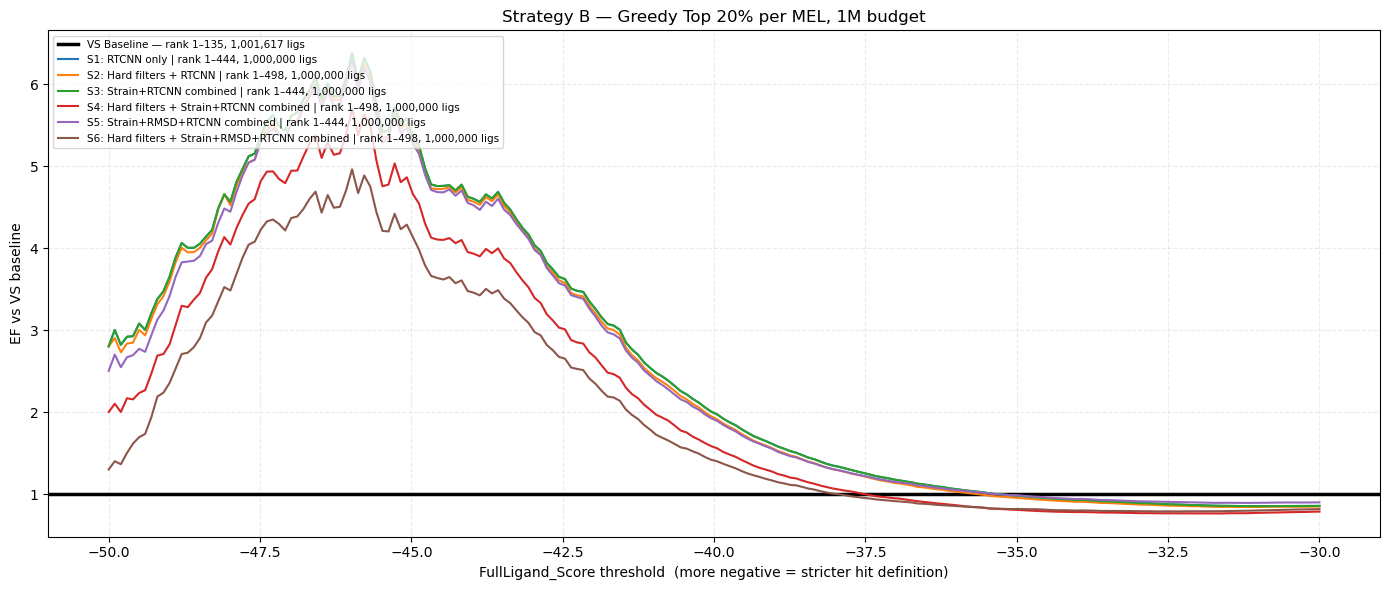

In [35]:
# ── Strategy B — EF curves vs VS baseline ─────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 6))

ax.axhline(1.0, color="k", linewidth=2.5,
           label=f"VS Baseline — rank 1–{baseline_df['mel_rank'].max()}, "
                 f"{len(baseline_ligands):,} ligs")

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]

for s, c in zip(range(1, 7), colors):
    r = results_b[s]
    ax.plot(
        thresholds, r["ef"], color=c,
        label=f"S{s}: {strategy_labels_b[s]} | "
              f"rank 1–{r['rank_max']}, {r['n_ligands']:,} ligs"
    )

ax.set_xlabel("FullLigand_Score threshold  (more negative = stricter hit definition)")
ax.set_ylabel("EF vs VS baseline")
ax.set_title(f"Strategy B — Greedy Top {int(FRACTION*100)}% per MEL, 1M budget")
ax.legend(fontsize=7.5, loc="upper left")
ax.grid(alpha=0.25, linestyle="--")
plt.tight_layout()
plt.show()


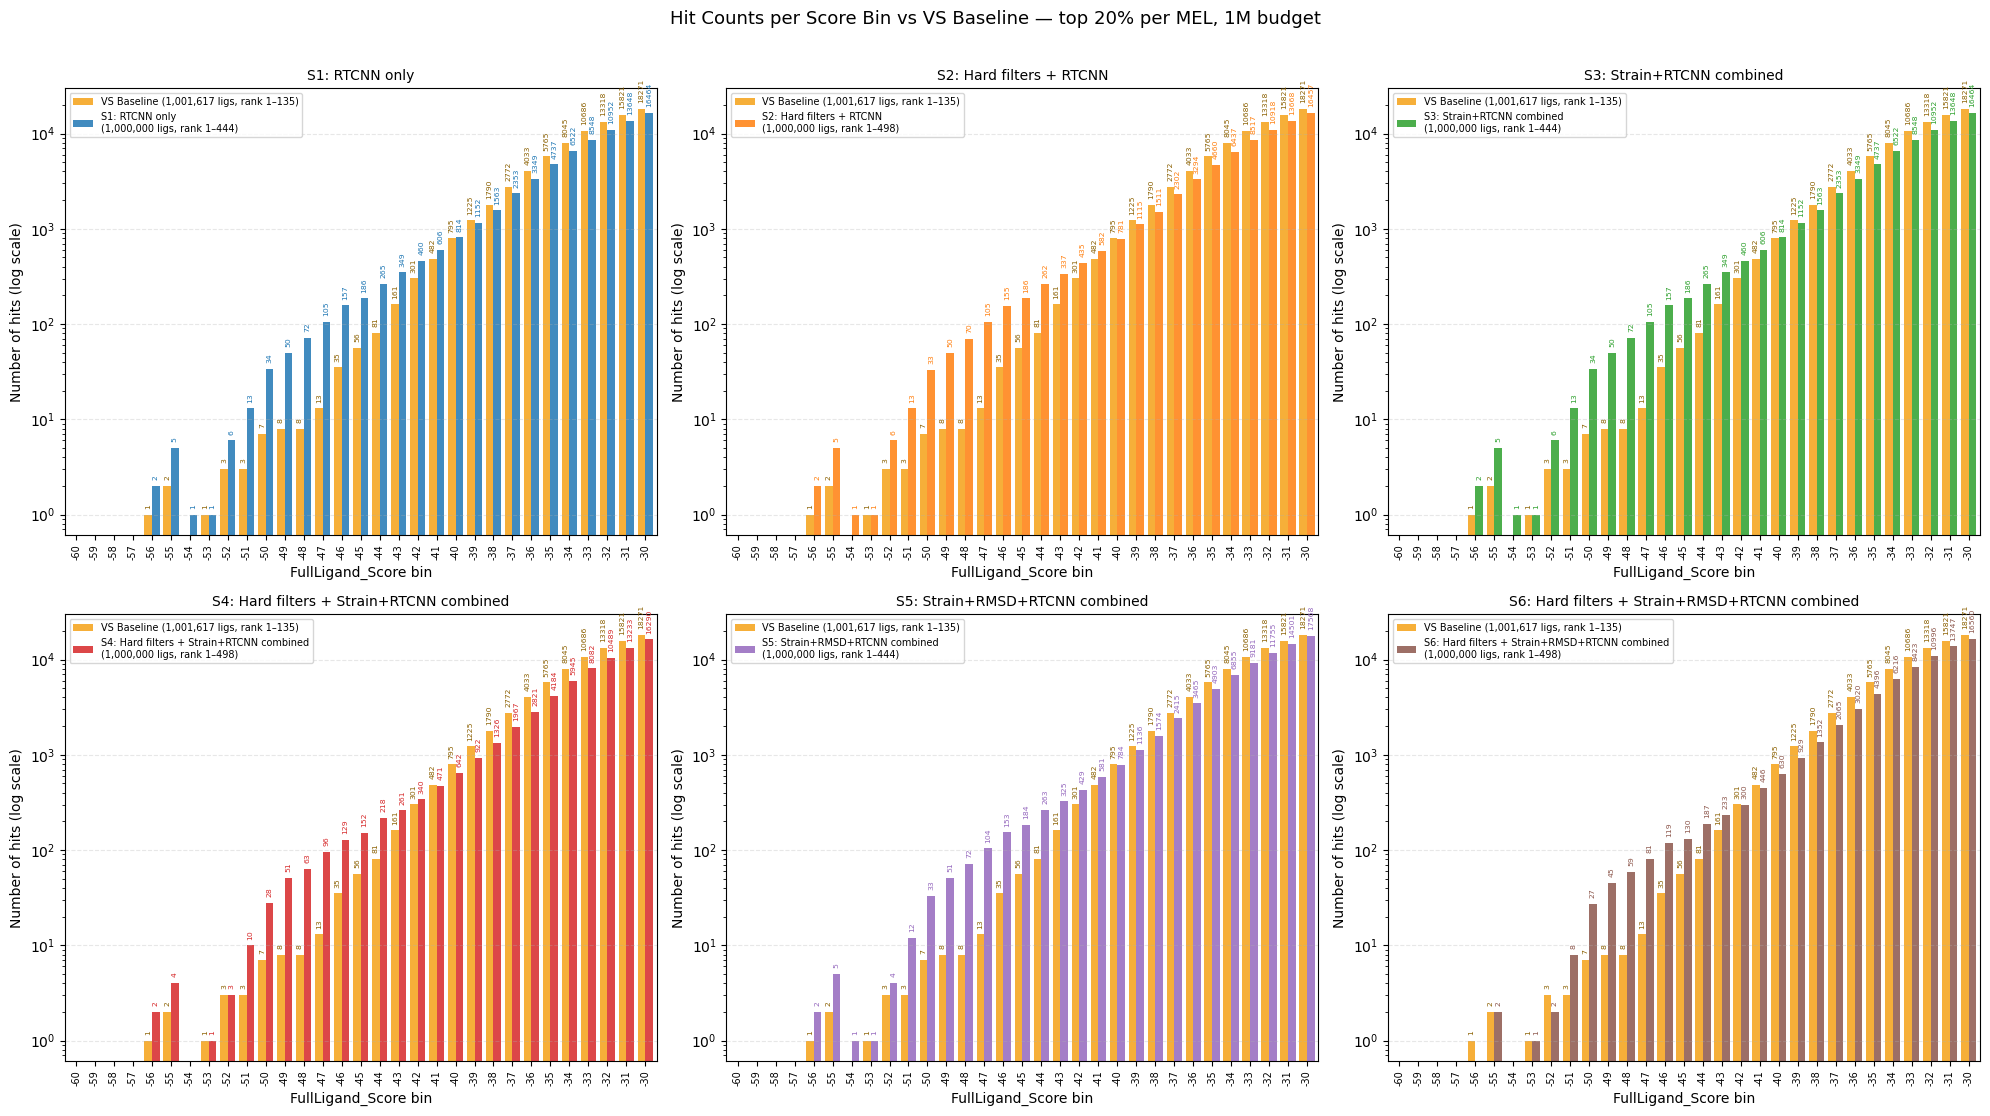

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Integer score bins [-50, -49, ..., -30], each bar = compounds in [b, b+1)
score_bins = np.arange(-60, -29, 1)

def count_per_bin(df, bins):
    counts = []
    for b in bins:
        counts.append(((df['FullLigand_Score'] >= b) & (df['FullLigand_Score'] < b + 1)).sum())
    return np.array(counts, dtype=float)

baseline_counts = count_per_bin(baseline_ligands, score_bins)

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

strat_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']
x = np.arange(len(score_bins))
width = 0.4

for idx, s in enumerate(range(1, 7)):
    ax = axes[idx]
    sel = results_b[s]['selected']
    strat_counts = count_per_bin(sel, score_bins)

    # Replace 0 with NaN so log scale doesn't break
    base_plot  = np.where(baseline_counts == 0, np.nan, baseline_counts)
    strat_plot = np.where(strat_counts    == 0, np.nan, strat_counts)

    bars_base  = ax.bar(x - width/2, base_plot,  width, color='#F5A623', alpha=0.9,
                        label=f'VS Baseline ({len(baseline_ligands):,} ligs, rank 1–{baseline_df["mel_rank"].max()})')
    bars_strat = ax.bar(x + width/2, strat_plot, width, color=strat_colors[idx], alpha=0.85,
                        label=f'S{s}: {strategy_labels_b[s]}\n({results_b[s]["n_ligands"]:,} ligs, rank 1–{results_b[s]["rank_max"]})')

    # Annotate counts on top of each bar
    for bar, count in zip(bars_base, baseline_counts):
        if count > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, count * 1.15,
                    str(int(count)), ha='center', va='bottom', fontsize=5.5, color='#8B6000', rotation=90)

    for bar, count in zip(bars_strat, strat_counts):
        if count > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, count * 1.15,
                    str(int(count)), ha='center', va='bottom', fontsize=5.5,
                    color=strat_colors[idx], rotation=90)

    ax.set_yscale('log')
    ax.set_xticks(x)
    ax.set_xticklabels([str(b) for b in score_bins], rotation=90, fontsize=7)
    ax.set_xlabel('FullLigand_Score bin')
    ax.set_ylabel('Number of hits (log scale)')
    ax.set_title(f'S{s}: {strategy_labels_b[s]}', fontsize=10)
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_xlim(-0.6, len(score_bins) - 0.4)

plt.suptitle(f'Hit Counts per Score Bin vs VS Baseline — top {int(FRACTION*100)}% per MEL, 1M budget',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


##### Strategy C — Softmax Sampling Per MEL (Probability-Weighted Selection, Then Walk MELs)
Core idea: Instead of a hard cutoff or fixed top fraction, use a softmax probability distribution over each MEL's synthon scores to sample synthons. Better-scoring synthons get higher probability of being selected, but lower-scoring synthons still have a chance. A temperature parameter T controls how aggressively the sampling favors the top scorers.

Step-by-step:
Walk MELs in docking-rank order (best MEL → worst MEL).
For each MEL, compute softmax probabilities over Synton RTCNN Score:
Negate the score first (since lower = better → higher probability after negation):
logits = -_score / T, then P(synthon_i) = exp(logits_i) / sum(exp(logits_j))
Sample min(PER_MEL_CAP, n_synthons, remaining_budget) synthons without replacement using these probabilities.

(Lower T → sharper distribution → top synthons dominate. Higher T → flatter → approaches uniform random.)
Bank leftover slots — if a MEL has fewer synthons than PER_MEL_CAP, take all of them and bank the unused slots into a remainder pool.
Second pass — after all MELs are processed, use the remainder pool to fill any gap to 1M by going back through MELs with leftover synthons.
Stop when the global total hits 1M.

How it differs from the Baseline:
MEL traversal order is identical (best MEL first).
Each MEL contributes at most PER_MEL_CAP synthons, selected probabilistically rather than uniformly — better synthons are more likely to be chosen but not guaranteed.
Introduces controlled stochasticity — results vary by random seed but are reproducible with fixed SEED.

What it does NOT do:
Does not apply a hard score floor — every synthon has some nonzero probability of being selected (though very low at low T).
Does not reorder MELs — poor MELs are still visited late regardless of their synthon quality.
Key parameters:

TEMPS — temperature sweep controlling selection sharpness. Current setting: TEMPS = [0.5, 1.0, 2.0]
PER_MEL_CAP — max synthons sampled per MEL per pass. Current setting: PER_MEL_CAP = 5,000
SEED — random seed for reproducibility. Current setting: SEED = 42

Scoring signal used (Options 1–6 control what _score is):
Option 1: _score = RTCNN_Score only
Option 2: hard filters (Strain > 15 or CoreRMSD > 2.0 Å → exclude), then _score = RTCNN_Score
Option 3: _score = mean(norm(Strain), norm(RTCNN_Score)) — no hard filters
Option 4: same combined score as Option 3, but hard filters applied first
Option 5: _score = mean(norm(Strain), norm(CoreRMSD), norm(RTCNN_Score)) — no hard filters
Option 6: same combined score as Option 5, but hard filters applied first


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BUDGET      = 1_000_000
PER_MEL_CAP = 5_000        # ← tune this: max synthons taken per MEL
TEMPS       = [0.5, 1.0, 2.0]
SEED        = 42

strategy_labels_c = {
    1: "RTCNN softmax only",
    2: "Hard filters + RTCNN softmax",
    3: "Strain+RTCNN combined softmax",
    4: "Hard filters + Strain+RTCNN combined softmax",
    5: "Strain+RMSD+RTCNN combined softmax",
    6: "Hard filters + Strain+RMSD+RTCNN combined softmax",
}

# ── helpers ────────────────────────────────────────────────────────────────

def hard_filter(df):
    return df[(df["Strain"] <= 15) & (df["CoreRmsd"] <= 2.0)].copy()

def global_minmax_combined(df, cols):
    d = df.copy()
    for c in cols:
        mn, mx = d[c].min(), d[c].max()
        d[f"_n_{c}"] = (d[c] - mn) / (mx - mn + 1e-9)
    d["_score"] = d[[f"_n_{c}" for c in cols]].mean(axis=1)
    return d

def prepare_scored_pool(synthon_df, strategy):
    df = hard_filter(synthon_df) if strategy in (2, 4, 6) else synthon_df.copy()
    if strategy in (1, 2):
        df["_score"] = df["RTCNN_Score"]
    elif strategy in (3, 4):
        df = global_minmax_combined(df, ["Strain", "RTCNN_Score"])
    else:
        df = global_minmax_combined(df, ["Strain", "CoreRmsd", "RTCNN_Score"])
    return df

def softmax_sample_df(mel_df, n_samples, T, rng):
    scores  = mel_df["_score"].values.astype(float)
    logits  = -scores / T          # negate: lower _score → higher probability
    logits -= logits.max()
    probs   = np.exp(logits)
    probs  /= probs.sum()
    chosen  = rng.choice(len(mel_df), size=n_samples, replace=False, p=probs)
    return mel_df.iloc[chosen]

def run_strategy_d(scored_df, mel_ranked, T, budget, per_mel_cap, seed=SEED):
    rng = np.random.default_rng(seed)

    available_keys = set(scored_df["key_norm"].unique())
    ranked_mels = [row for _, row in mel_ranked.iterrows()
                   if row["key_norm"] in available_keys]
    if len(ranked_mels) == 0:
        return pd.DataFrame(), 0, 0, None, None

    mel_groups = {k: g for k, g in scored_df.groupby("key_norm")}

    # ── First pass: walk MELs in rank order, cap per MEL, stop at budget ──
    first_sel    = []
    remainders   = {}
    total_so_far = 0

    for row in ranked_mels:
        if total_so_far >= budget:
            break
        key    = row["key_norm"]
        mel_df = mel_groups[key]
        n      = len(mel_df)

        # take = min(cap, available synthons, remaining budget slots)
        take = min(per_mel_cap, n, budget - total_so_far)

        if take == n:
            # MEL is smaller than both cap and remaining budget → take all
            first_sel.append(mel_df)
        else:
            # Cap or budget is binding → softmax sample exactly `take` synthons
            sampled = softmax_sample_df(mel_df, take, T, rng)
            first_sel.append(sampled)
            # Store leftovers for second pass (only relevant if budget not yet hit)
            sampled_idx = set(sampled.index)
            remainders[key] = mel_df[~mel_df.index.isin(sampled_idx)]

        total_so_far += take

    # ── Second pass: fill any remaining budget from leftover pools ─────────
    # (activates only when many MELs were tiny and first pass < budget)
    remaining  = budget - total_so_far
    second_sel = []

    for row in ranked_mels:
        if remaining <= 0:
            break
        key = row["key_norm"]
        if key not in remainders:
            continue
        leftover = remainders[key]
        n_take   = min(remaining, len(leftover))
        extra    = (softmax_sample_df(leftover, n_take, T, rng)
                    if n_take < len(leftover) else leftover)
        second_sel.append(extra)
        remaining -= n_take

    # ── Combine & stats ───────────────────────────────────────────────────
    all_parts = first_sel + second_sel
    selected  = pd.concat(all_parts, ignore_index=True) if all_parts else pd.DataFrame()

    sel_keys = set(selected["key_norm"].unique())
    contrib  = [r for r in ranked_mels if r["key_norm"] in sel_keys]
    rank_min = min(r["mel_rank"] for r in contrib) if contrib else None
    rank_max = max(r["mel_rank"] for r in contrib) if contrib else None

    return selected, len(contrib), len(selected), rank_min, rank_max

# ── Pre-compute scored pools once per strategy ────────────────────────────

print("=== Preparing scored pools ===")
scored_cache = {}
for s in range(1, 7):
    scored_cache[s] = prepare_scored_pool(synthon_ground_truth, s)
    print(f"S{s} [{strategy_labels_c[s]}]: {len(scored_cache[s]):,} synthons in pool")
print()

# ── Run all 6 strategies × 3 temperatures ────────────────────────────────

print("=== Running Strategy D (softmax sampling) ===")
print(f"Per-MEL cap   : {PER_MEL_CAP:,} synthons")
print(f"Baseline (VS) : {len(baseline_df)} MELs, "
      f"rank {baseline_df['mel_rank'].min()}–{baseline_df['mel_rank'].max()}, "
      f"{len(baseline_ligands):,} ligands\n")

results_c = {}
for s in range(1, 7):
    for T in TEMPS:
        sel, n_mels, n_ligs, r_min, r_max = run_strategy_d(
            scored_cache[s], mel_ranked, T, BUDGET, PER_MEL_CAP
        )
        results_c[(s, T)] = dict(
            selected  = sel,
            n_mels    = n_mels,
            n_ligands = n_ligs,
            rank_min  = r_min,
            rank_max  = r_max,
            ef        = compute_ef_vs_baseline(sel, baseline_ligands, thresholds),
        )
        print(f"  S{s} T={T:.1f} | cap={PER_MEL_CAP:,}/MEL | "
              f"{n_mels} MELs | rank {r_min}–{r_max} | {n_ligs:,} ligs")
    print()


=== Preparing scored pools ===
S1 [RTCNN softmax only]: 10,046,534 synthons in pool
S2 [Hard filters + RTCNN softmax]: 8,508,188 synthons in pool
S3 [Strain+RTCNN combined softmax]: 10,046,534 synthons in pool
S4 [Hard filters + Strain+RTCNN combined softmax]: 8,508,188 synthons in pool
S5 [Strain+RMSD+RTCNN combined softmax]: 10,046,534 synthons in pool
S6 [Hard filters + Strain+RMSD+RTCNN combined softmax]: 8,508,188 synthons in pool

=== Running Strategy D (softmax sampling) ===
Per-MEL cap   : 5,000 synthons
Baseline (VS) : 78 MELs, rank 1–135, 1,001,617 ligands

  S1 T=0.5 | cap=5,000/MEL | 277 MELs | rank 1–456 | 1,000,000 ligs
  S1 T=1.0 | cap=5,000/MEL | 277 MELs | rank 1–456 | 1,000,000 ligs
  S1 T=2.0 | cap=5,000/MEL | 277 MELs | rank 1–456 | 1,000,000 ligs

  S2 T=0.5 | cap=5,000/MEL | 278 MELs | rank 1–457 | 1,000,000 ligs
  S2 T=1.0 | cap=5,000/MEL | 278 MELs | rank 1–457 | 1,000,000 ligs
  S2 T=2.0 | cap=5,000/MEL | 278 MELs | rank 1–457 | 1,000,000 ligs

  S3 T=0.5 | cap

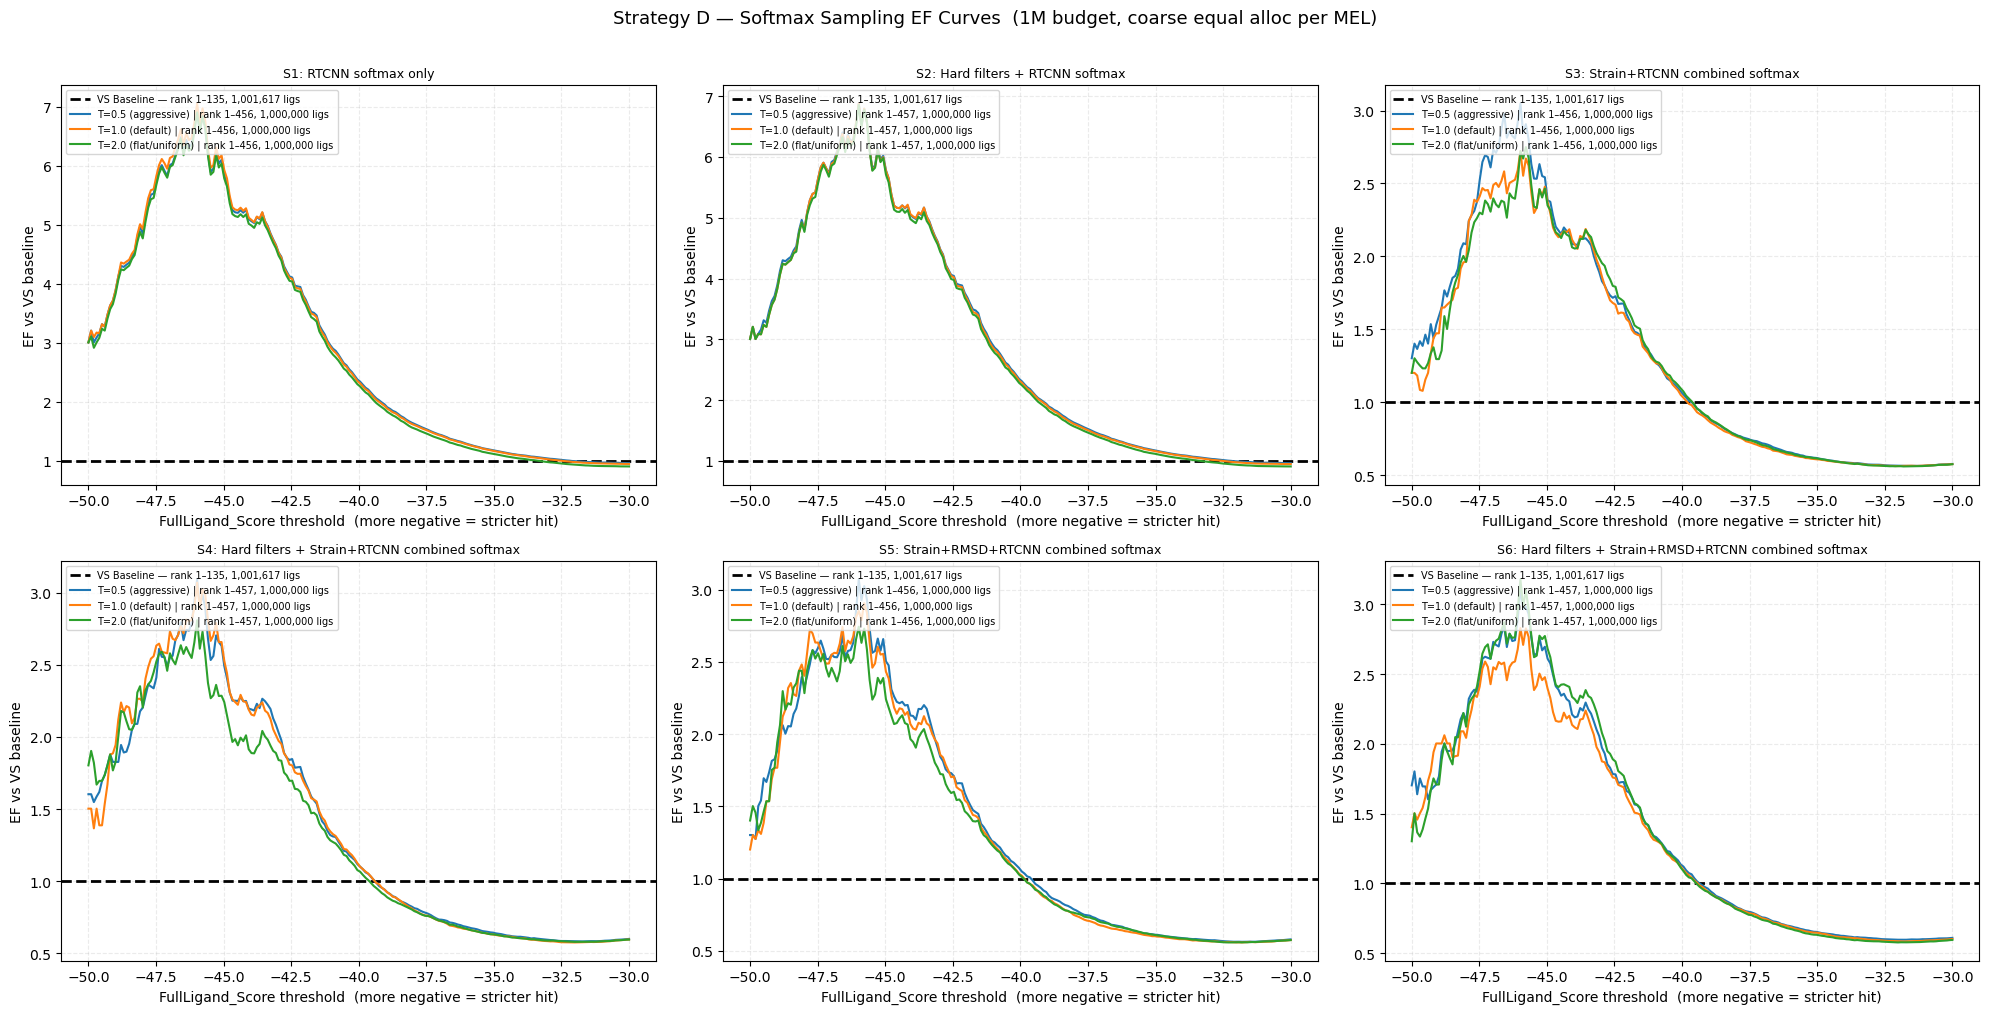

In [38]:
# ── Strategy C — EF curves ─────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

T_colors = {0.5: "tab:blue", 1.0: "tab:orange", 2.0: "tab:green"}
T_labels = {0.5: "T=0.5 (aggressive)", 1.0: "T=1.0 (default)", 2.0: "T=2.0 (flat/uniform)"}

for idx, s in enumerate(range(1, 7)):
    ax = axes[idx]

    ax.axhline(1.0, color="k", linewidth=2, linestyle="--",
               label=f"VS Baseline — rank 1–{baseline_df['mel_rank'].max()}, "
                     f"{len(baseline_ligands):,} ligs")

    for T in TEMPS:
        r = results_c[(s, T)]
        ax.plot(thresholds, r["ef"], color=T_colors[T],
                label=f"{T_labels[T]} | rank 1–{r['rank_max']}, {r['n_ligands']:,} ligs")

    ax.set_xlabel("FullLigand_Score threshold  (more negative = stricter hit)")
    ax.set_ylabel("EF vs VS baseline")
    ax.set_title(f"S{s}: {strategy_labels_c[s]}", fontsize=9)
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(alpha=0.25, linestyle="--")

plt.suptitle(
    "Strategy D — Softmax Sampling EF Curves  (1M budget, coarse equal alloc per MEL)",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()


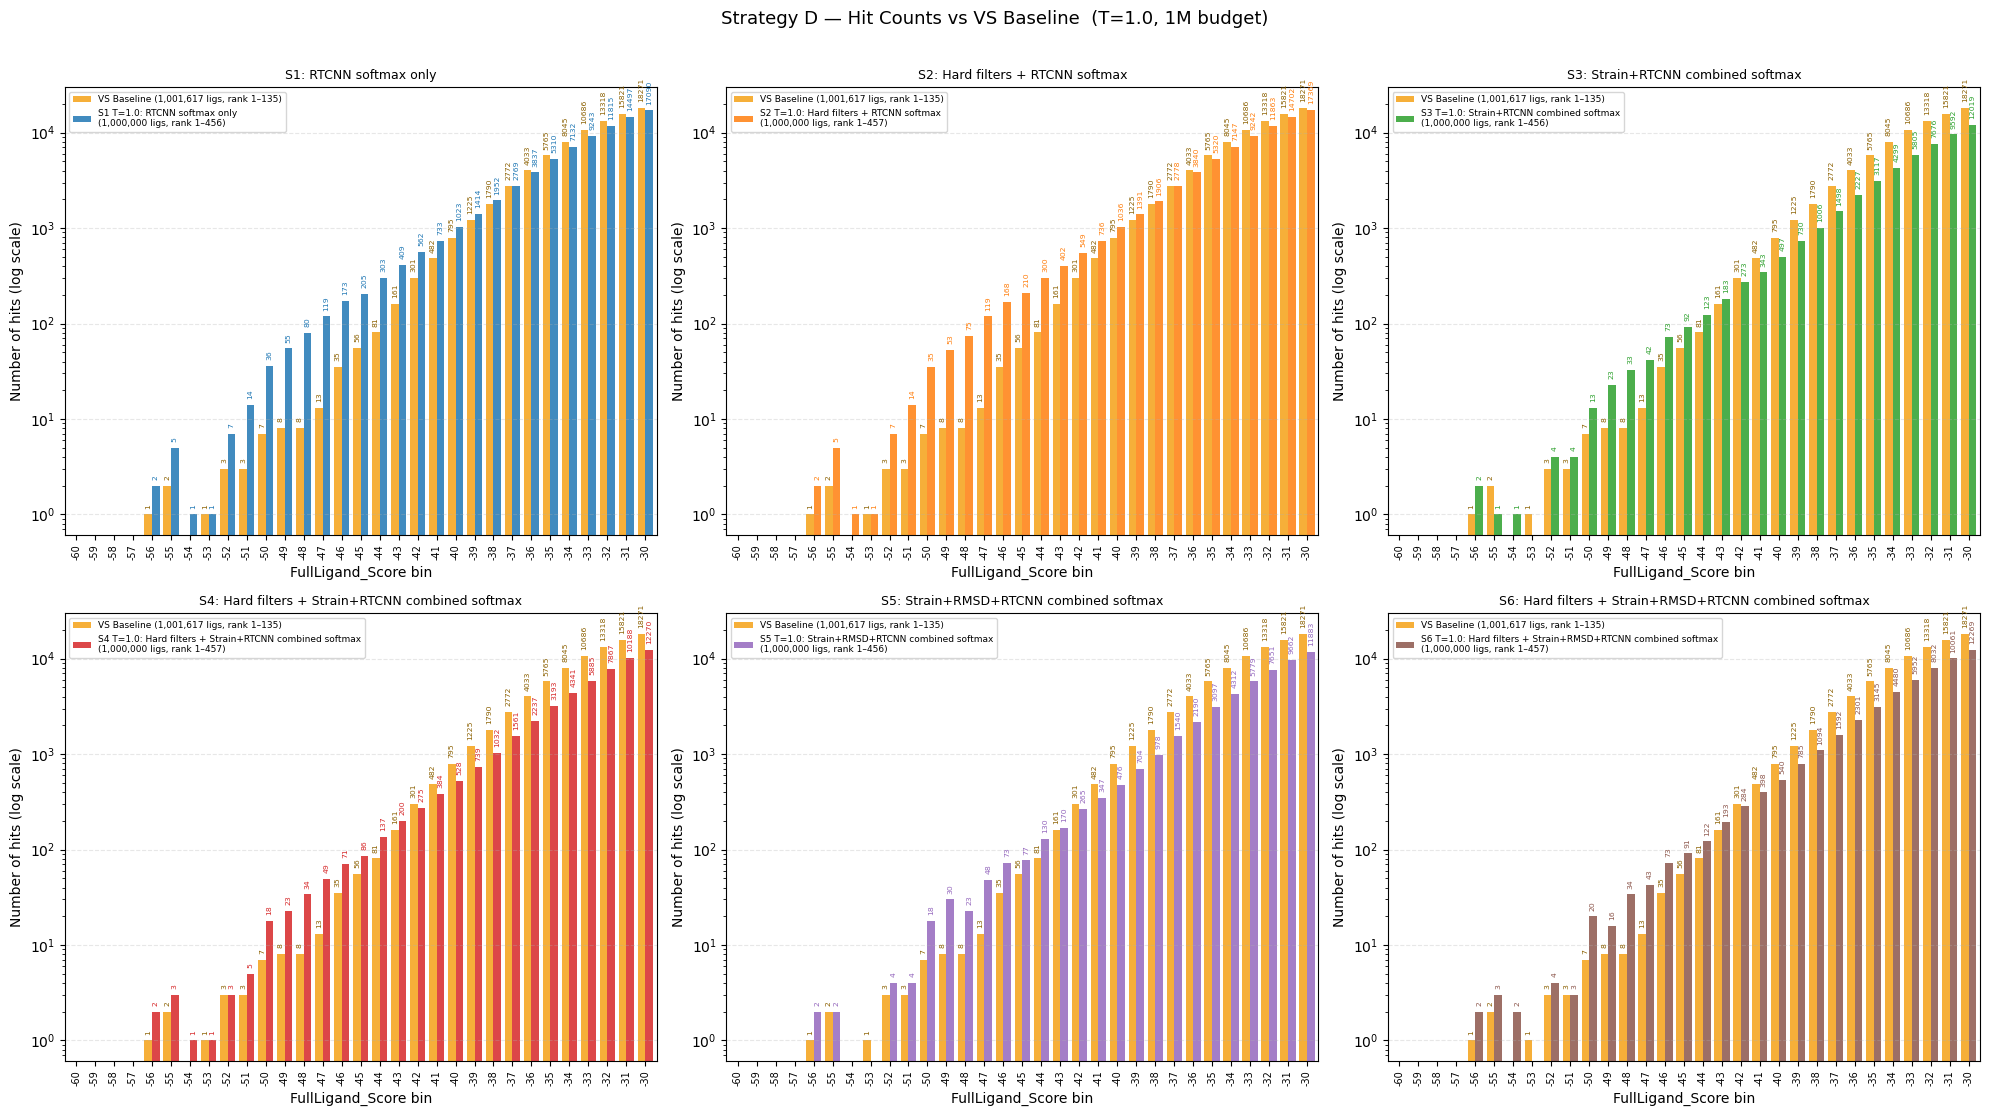

In [39]:
# ── Strategy C — Hit-count histograms at T=1.0 ────────────────────────────

T_show     = 1.0
score_bins = np.arange(-60, -29, 1)

def count_per_bin_d(df, bins):
    return np.array(
        [((df["FullLigand_Score"] >= b) & (df["FullLigand_Score"] < b + 1)).sum()
         for b in bins],
        dtype=float,
    )

baseline_counts_d = count_per_bin_d(baseline_ligands, score_bins)

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

strat_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]
x     = np.arange(len(score_bins))
width = 0.4

for idx, s in enumerate(range(1, 7)):
    ax  = axes[idx]
    r   = results_c[(s, T_show)]
    sel = r["selected"]
    strat_counts = count_per_bin_d(sel, score_bins)

    base_plot   = np.where(baseline_counts_d == 0, np.nan, baseline_counts_d)
    strat_plot  = np.where(strat_counts      == 0, np.nan, strat_counts)

    bars_base  = ax.bar(
        x - width / 2, base_plot, width, color="#F5A623", alpha=0.9,
        label=f"VS Baseline ({len(baseline_ligands):,} ligs, rank 1–{baseline_df['mel_rank'].max()})",
    )
    bars_strat = ax.bar(
        x + width / 2, strat_plot, width, color=strat_colors[idx], alpha=0.85,
        label=f"S{s} T={T_show}: {strategy_labels_c[s]}\n"
              f"({r['n_ligands']:,} ligs, rank 1–{r['rank_max']})",
    )

    for bar, count in zip(bars_base, baseline_counts_d):
        if count > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, count * 1.15,
                    str(int(count)), ha="center", va="bottom",
                    fontsize=5.5, color="#8B6000", rotation=90)
    for bar, count in zip(bars_strat, strat_counts):
        if count > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, count * 1.15,
                    str(int(count)), ha="center", va="bottom",
                    fontsize=5.5, color=strat_colors[idx], rotation=90)

    ax.set_yscale("log")
    ax.set_xticks(x)
    ax.set_xticklabels([str(b) for b in score_bins], rotation=90, fontsize=7)
    ax.set_xlabel("FullLigand_Score bin")
    ax.set_ylabel("Number of hits (log scale)")
    ax.set_title(f"S{s}: {strategy_labels_c[s]}", fontsize=9)
    ax.legend(fontsize=6.5, loc="upper left")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.set_xlim(-0.6, len(score_bins) - 0.4)

plt.suptitle(
    f"Strategy D — Hit Counts vs VS Baseline  (T={T_show}, 1M budget)",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()


##### Strategy D — Global Rank with Per-MEL Cap (Ignore MEL Order, Select by Synthon RTCNN Score Globally)
Core idea: Pool all synthons from all MELs into one global list, rank them by synton RTCNN Score, and greedily take the best-scoring synthons subject to a per-MEL cap. MEL docking rank is completely ignored — a great synthon from a mediocre MEL can be selected ahead of a poor synthon from a top MEL.

Step-by-step:
For each MEL, pre-select its top PER_MEL_CAP synthons by synton RTCNN Score (best to worst). This enforces diversity — no single MEL can dominate the entire 1M budget.
Pool all pre-selected synthons across all MELs into one global list. Sort globally by synton RTCNN Score best to worst.
Take the top 1M synthons from this global sorted list. Stop at 1M.

How it differs from the Baseline:
MEL traversal order is completely discarded — this is the fundamental structural difference from all other strategies.
A synthon from MEL rank #300 can be selected before a synthon from MEL rank #1, purely based on its synton RTCNN Score.
The per-MEL cap is the only diversity guardrail preventing a single large MEL from filling the entire budget.
All MELs are eligible contributors regardless of their MEL docking rank.

What it does NOT do:
Does not walk MELs sequentially — the concept of MEL rank order is irrelevant here.
Does not sample probabilistically — selection is fully deterministic given _score and PER_MEL_CAP.

Key parameter: CAPS — per-MEL cap sweep controlling exploitation vs. diversity tradeoff.
Current setting: CAPS = [5,000, 10,000, 15,000]
(Lower cap → more MELs contribute, higher diversity. Higher cap → fewer MELs dominate, more exploitation of top-scoring synthons.)

Scoring signal used (Options 1–6 control what _score is):
Option 1: _score = RTCNN_Score only
Option 2: hard filters (Strain > 15 or CoreRMSD > 2.0 Å → exclude), then _score = RTCNN_Score
Option 3: _score = mean(norm(Strain), norm(RTCNN_Score)) — no hard filters
Option 4: same combined score as Option 3, but hard filters applied first
Option 5: _score = mean(norm(Strain), norm(CoreRMSD), norm(RTCNN_Score)) — no hard filters
Option 6: same combined score as Option 5, but hard filters applied first


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BUDGET = 1_000_000
CAPS   = [10_000, 15_000]    # ← per-MEL cap sweep

strategy_labels_d = {
    1: "RTCNN global rank only",
    2: "Hard filters + RTCNN global rank",
    3: "Strain+RTCNN combined global rank",
    4: "Hard filters + Strain+RTCNN combined global rank",
    5: "Strain+RMSD+RTCNN combined global rank",
    6: "Hard filters + Strain+RMSD+RTCNN combined global rank",
}

# ── helpers ────────────────────────────────────────────────────────────────

def hard_filter(df):
    return df[(df["Strain"] <= 15) & (df["CoreRmsd"] <= 2.0)].copy()

def global_minmax_combined(df, cols):
    d = df.copy()
    for c in cols:
        mn, mx = d[c].min(), d[c].max()
        d[f"_n_{c}"] = (d[c] - mn) / (mx - mn + 1e-9)
    d["_score"] = d[[f"_n_{c}" for c in cols]].mean(axis=1)
    return d

def prepare_scored_pool(synthon_df, strategy):
    """Filter + score. Returns df with _score (lower = better)."""
    df = hard_filter(synthon_df) if strategy in (2, 4, 6) else synthon_df.copy()
    if strategy in (1, 2):
        df["_score"] = df["RTCNN_Score"]
    elif strategy in (3, 4):
        df = global_minmax_combined(df, ["Strain", "RTCNN_Score"])
    else:
        df = global_minmax_combined(df, ["Strain", "CoreRmsd", "RTCNN_Score"])
    return df

def run_strategy_d(scored_df, mel_ranked, per_mel_cap, budget):
    """
    Deterministic global rank + per-MEL cap. No sampling, no temperature.
    1. For each MEL keep only its top per_mel_cap synthons by _score.
    2. Pool everything, sort globally, take top budget.
    """
    # Step 1: cap per MEL
    pool = (scored_df
            .sort_values("_score", ascending=True)
            .groupby("key_norm", group_keys=False)
            .head(per_mel_cap))

    # Step 2: global sort, take top budget
    selected = pool.sort_values("_score", ascending=True).head(budget)

    # Step 3: stats
    mel_rank_lookup   = dict(zip(mel_ranked["key_norm"], mel_ranked["mel_rank"]))
    contributing_keys = selected["key_norm"].unique()
    mel_ranks = [mel_rank_lookup[k] for k in contributing_keys if k in mel_rank_lookup]

    n_mels   = len(contributing_keys)
    n_capped = int((pool.groupby("key_norm").size() >= per_mel_cap).sum())
    rank_min = min(mel_ranks) if mel_ranks else None
    rank_max = max(mel_ranks) if mel_ranks else None

    return selected, n_mels, len(selected), rank_min, rank_max, n_capped

# ── Pre-score once per strategy (reused across all cap values) ─────────────

print("=== Preparing scored pools ===")
scored_cache_d = {}
for s in range(1, 7):
    scored_cache_d[s] = prepare_scored_pool(synthon_ground_truth, s)
    print(f"S{s} [{strategy_labels_d[s]}]: {len(scored_cache_d[s]):,} synthons in pool")
print()

# ── Run 6 strategies × 3 cap values ───────────────────────────────────────

print("=== Running Strategy D (global rank + per-MEL cap) ===")
print(f"Caps          : {CAPS}")
print(f"Baseline (VS) : {len(baseline_df)} MELs, "
      f"rank {baseline_df['mel_rank'].min()}–{baseline_df['mel_rank'].max()}, "
      f"{len(baseline_ligands):,} ligands\n")

results_d = {}
for s in range(1, 7):
    for cap in CAPS:
        sel, n_mels, n_ligs, r_min, r_max, n_capped = run_strategy_d(
            scored_cache_d[s], mel_ranked, cap, BUDGET
        )
        results_d[(s, cap)] = dict(
            selected  = sel,
            n_mels    = n_mels,
            n_ligands = n_ligs,
            rank_min  = r_min,
            rank_max  = r_max,
            n_capped  = n_capped,
            ef        = compute_ef_vs_baseline(sel, baseline_ligands, thresholds),
        )
        print(f"  S{s} cap={cap:,} | {n_mels} MELs | rank {r_min}–{r_max} | "
              f"{n_capped} MELs hit cap | {n_ligs:,} ligs")
    print()


=== Preparing scored pools ===
S1 [RTCNN global rank only]: 10,046,534 synthons in pool
S2 [Hard filters + RTCNN global rank]: 8,508,188 synthons in pool
S3 [Strain+RTCNN combined global rank]: 10,046,534 synthons in pool
S4 [Hard filters + Strain+RTCNN combined global rank]: 8,508,188 synthons in pool
S5 [Strain+RMSD+RTCNN combined global rank]: 10,046,534 synthons in pool
S6 [Hard filters + Strain+RMSD+RTCNN combined global rank]: 8,508,188 synthons in pool

=== Running Strategy D (global rank + per-MEL cap) ===
Caps          : [10000, 15000]
Baseline (VS) : 78 MELs, rank 1–135, 1,001,617 ligands

  S1 cap=10,000 | 486 MELs | rank 1–900 | 354 MELs hit cap | 1,000,000 ligs
  S1 cap=15,000 | 485 MELs | rank 1–900 | 307 MELs hit cap | 1,000,000 ligs

  S2 cap=10,000 | 481 MELs | rank 1–900 | 339 MELs hit cap | 1,000,000 ligs
  S2 cap=15,000 | 480 MELs | rank 1–900 | 275 MELs hit cap | 1,000,000 ligs

  S3 cap=10,000 | 486 MELs | rank 1–900 | 354 MELs hit cap | 1,000,000 ligs
  S3 cap=15

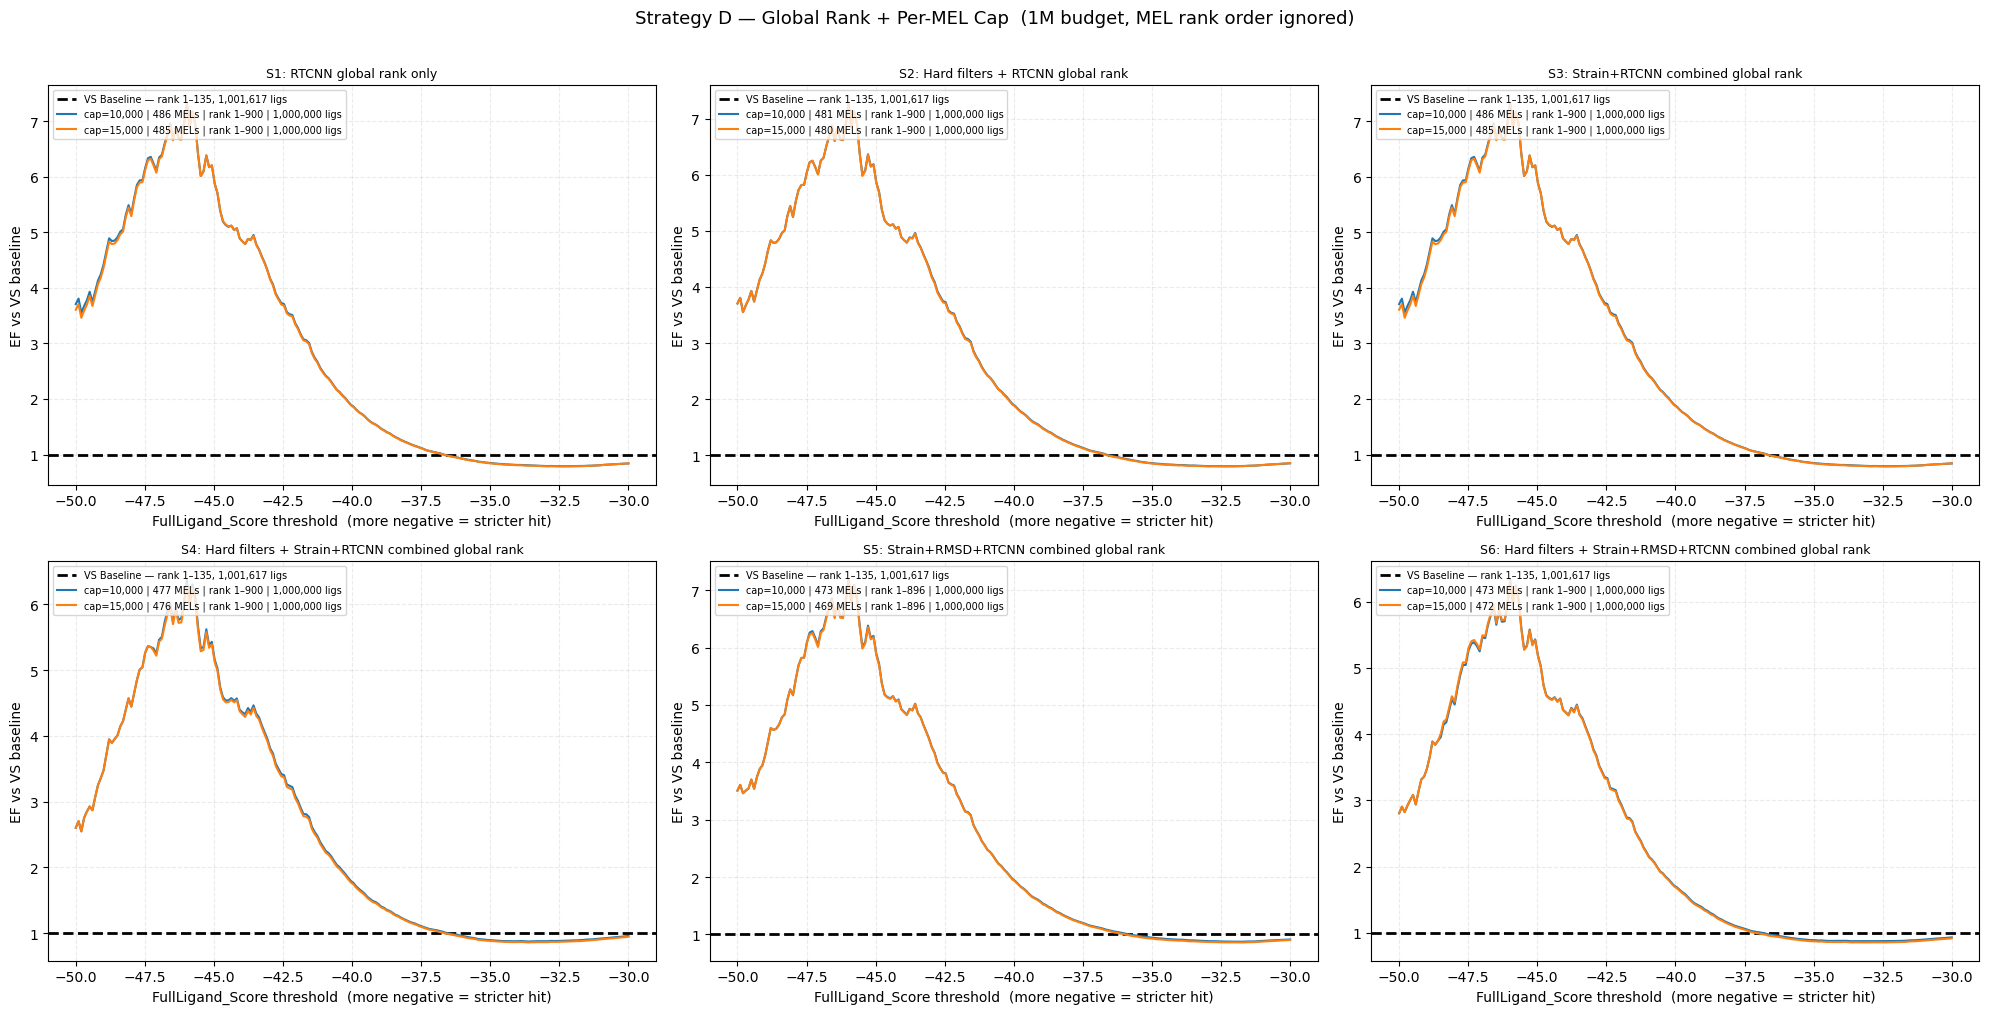

In [41]:
# ── Strategy D — EF curves ─────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

_palette   = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
cap_colors = {cap: _palette[i] for i, cap in enumerate(CAPS)}
cap_labels = {cap: f"cap={cap:,}" for cap in CAPS}

for idx, s in enumerate(range(1, 7)):
    ax = axes[idx]

    ax.axhline(1.0, color="k", linewidth=2, linestyle="--",
               label=f"VS Baseline — rank 1–{baseline_df['mel_rank'].max()}, "
                     f"{len(baseline_ligands):,} ligs")

    for cap in CAPS:
        r = results_d[(s, cap)]
        ax.plot(
            thresholds, r["ef"], color=cap_colors[cap],
            label=f"{cap_labels[cap]} | {r['n_mels']} MELs | "
                  f"rank {r['rank_min']}–{r['rank_max']} | {r['n_ligands']:,} ligs"
        )

    ax.set_xlabel("FullLigand_Score threshold  (more negative = stricter hit)")
    ax.set_ylabel("EF vs VS baseline")
    ax.set_title(f"S{s}: {strategy_labels_d[s]}", fontsize=9)
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(alpha=0.25, linestyle="--")

plt.suptitle(
    "Strategy D — Global Rank + Per-MEL Cap  (1M budget, MEL rank order ignored)",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()


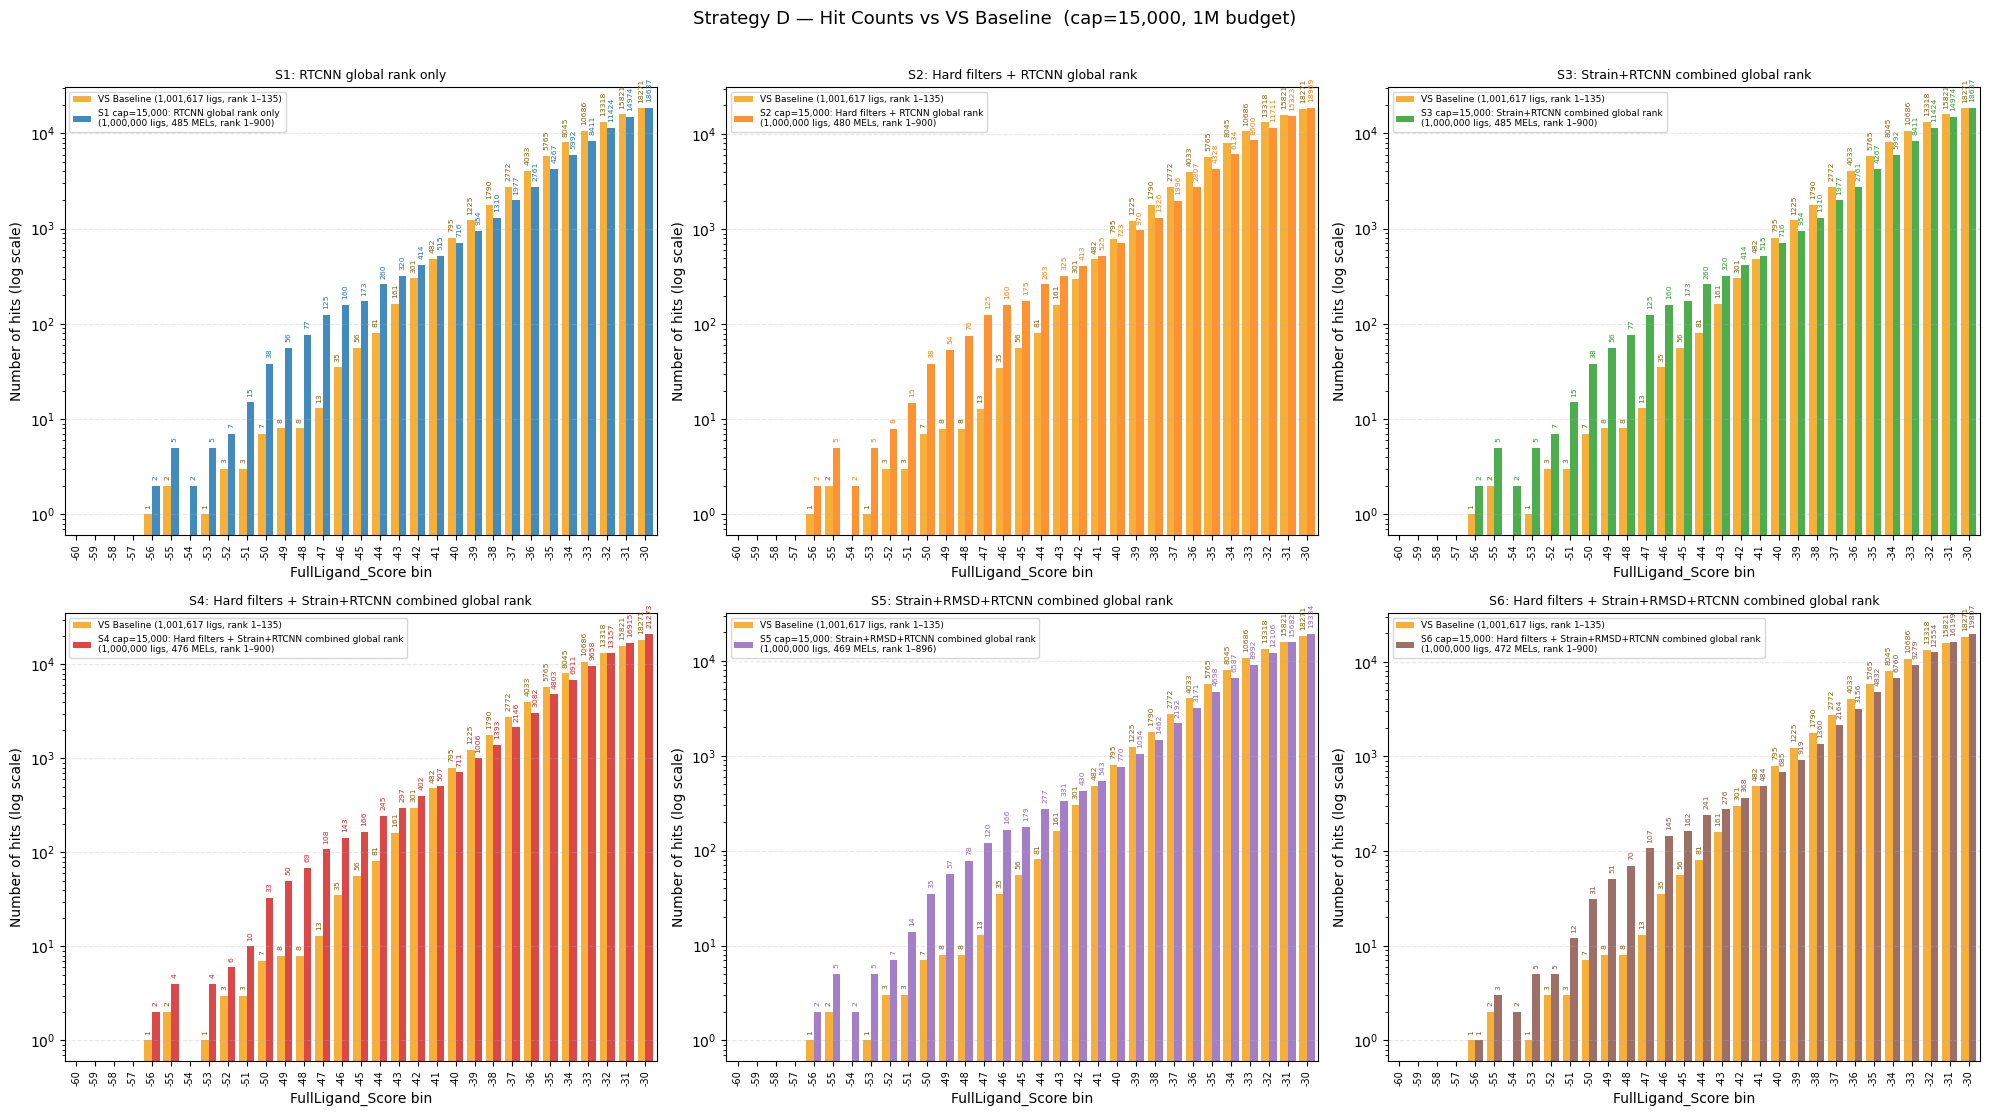

In [42]:
# ── Strategy D — Hit-count histograms (middle cap value) ──────────────────

cap_show   = CAPS[1]     # middle value, e.g. 5,000
score_bins = np.arange(-60, -29, 1)

def count_per_bin_d(df, bins):
    return np.array(
        [((df["FullLigand_Score"] >= b) & (df["FullLigand_Score"] < b + 1)).sum()
         for b in bins],
        dtype=float,
    )

baseline_counts_d = count_per_bin_d(baseline_ligands, score_bins)

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

strat_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]
x     = np.arange(len(score_bins))
width = 0.4

for idx, s in enumerate(range(1, 7)):
    ax           = axes[idx]
    r            = results_d[(s, cap_show)]
    sel          = r["selected"]
    strat_counts = count_per_bin_d(sel, score_bins)

    base_plot  = np.where(baseline_counts_d == 0, np.nan, baseline_counts_d)
    strat_plot = np.where(strat_counts      == 0, np.nan, strat_counts)

    bars_base  = ax.bar(
        x - width / 2, base_plot, width, color="#F5A623", alpha=0.9,
        label=f"VS Baseline ({len(baseline_ligands):,} ligs, rank 1–{baseline_df['mel_rank'].max()})",
    )
    bars_strat = ax.bar(
        x + width / 2, strat_plot, width, color=strat_colors[idx], alpha=0.85,
        label=f"S{s} cap={cap_show:,}: {strategy_labels_d[s]}\n"
              f"({r['n_ligands']:,} ligs, {r['n_mels']} MELs, rank {r['rank_min']}–{r['rank_max']})",
    )

    for bar, count in zip(bars_base, baseline_counts_d):
        if count > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, count * 1.15,
                    str(int(count)), ha="center", va="bottom",
                    fontsize=5.5, color="#8B6000", rotation=90)
    for bar, count in zip(bars_strat, strat_counts):
        if count > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, count * 1.15,
                    str(int(count)), ha="center", va="bottom",
                    fontsize=5.5, color=strat_colors[idx], rotation=90)

    ax.set_yscale("log")
    ax.set_xticks(x)
    ax.set_xticklabels([str(b) for b in score_bins], rotation=90, fontsize=7)
    ax.set_xlabel("FullLigand_Score bin")
    ax.set_ylabel("Number of hits (log scale)")
    ax.set_title(f"S{s}: {strategy_labels_d[s]}", fontsize=9)
    ax.legend(fontsize=6.5, loc="upper left")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.set_xlim(-0.6, len(score_bins) - 0.4)

plt.suptitle(
    f"Strategy D — Hit Counts vs VS Baseline  (cap={cap_show:,}, 1M budget)",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()


#### What Is The Best Strategy?

=== Strategy Ranking (sorted by EF AUC — mean EF across all thresholds) ===

EF sweep range : -60 to -40
Hit thresholds : [-55, -53, -51, -49, -47]

                                                  strategy_name                  config  n_mels  rank_max  n_ligands  ef_auc  ef@-55  ef@-53  ef@-51  ef@-49  ef@-47
1                                  D-S1: RTCNN global rank only              cap=10,000     486       900    1000000   4.041   2.003   3.005   3.148   4.419   6.313
2                       D-S3: Strain+RTCNN combined global rank              cap=10,000     486       900    1000000   4.041   2.003   3.005   3.148   4.419   6.313
3                        D-S2: Hard filters + RTCNN global rank              cap=10,000     481       900    1000000   4.029   2.003   3.005   3.148   4.419   6.222
4                        D-S2: Hard filters + RTCNN global rank              cap=15,000     480       900    1000000   4.025   2.003   3.005   3.148   4.419   6.222
5                         

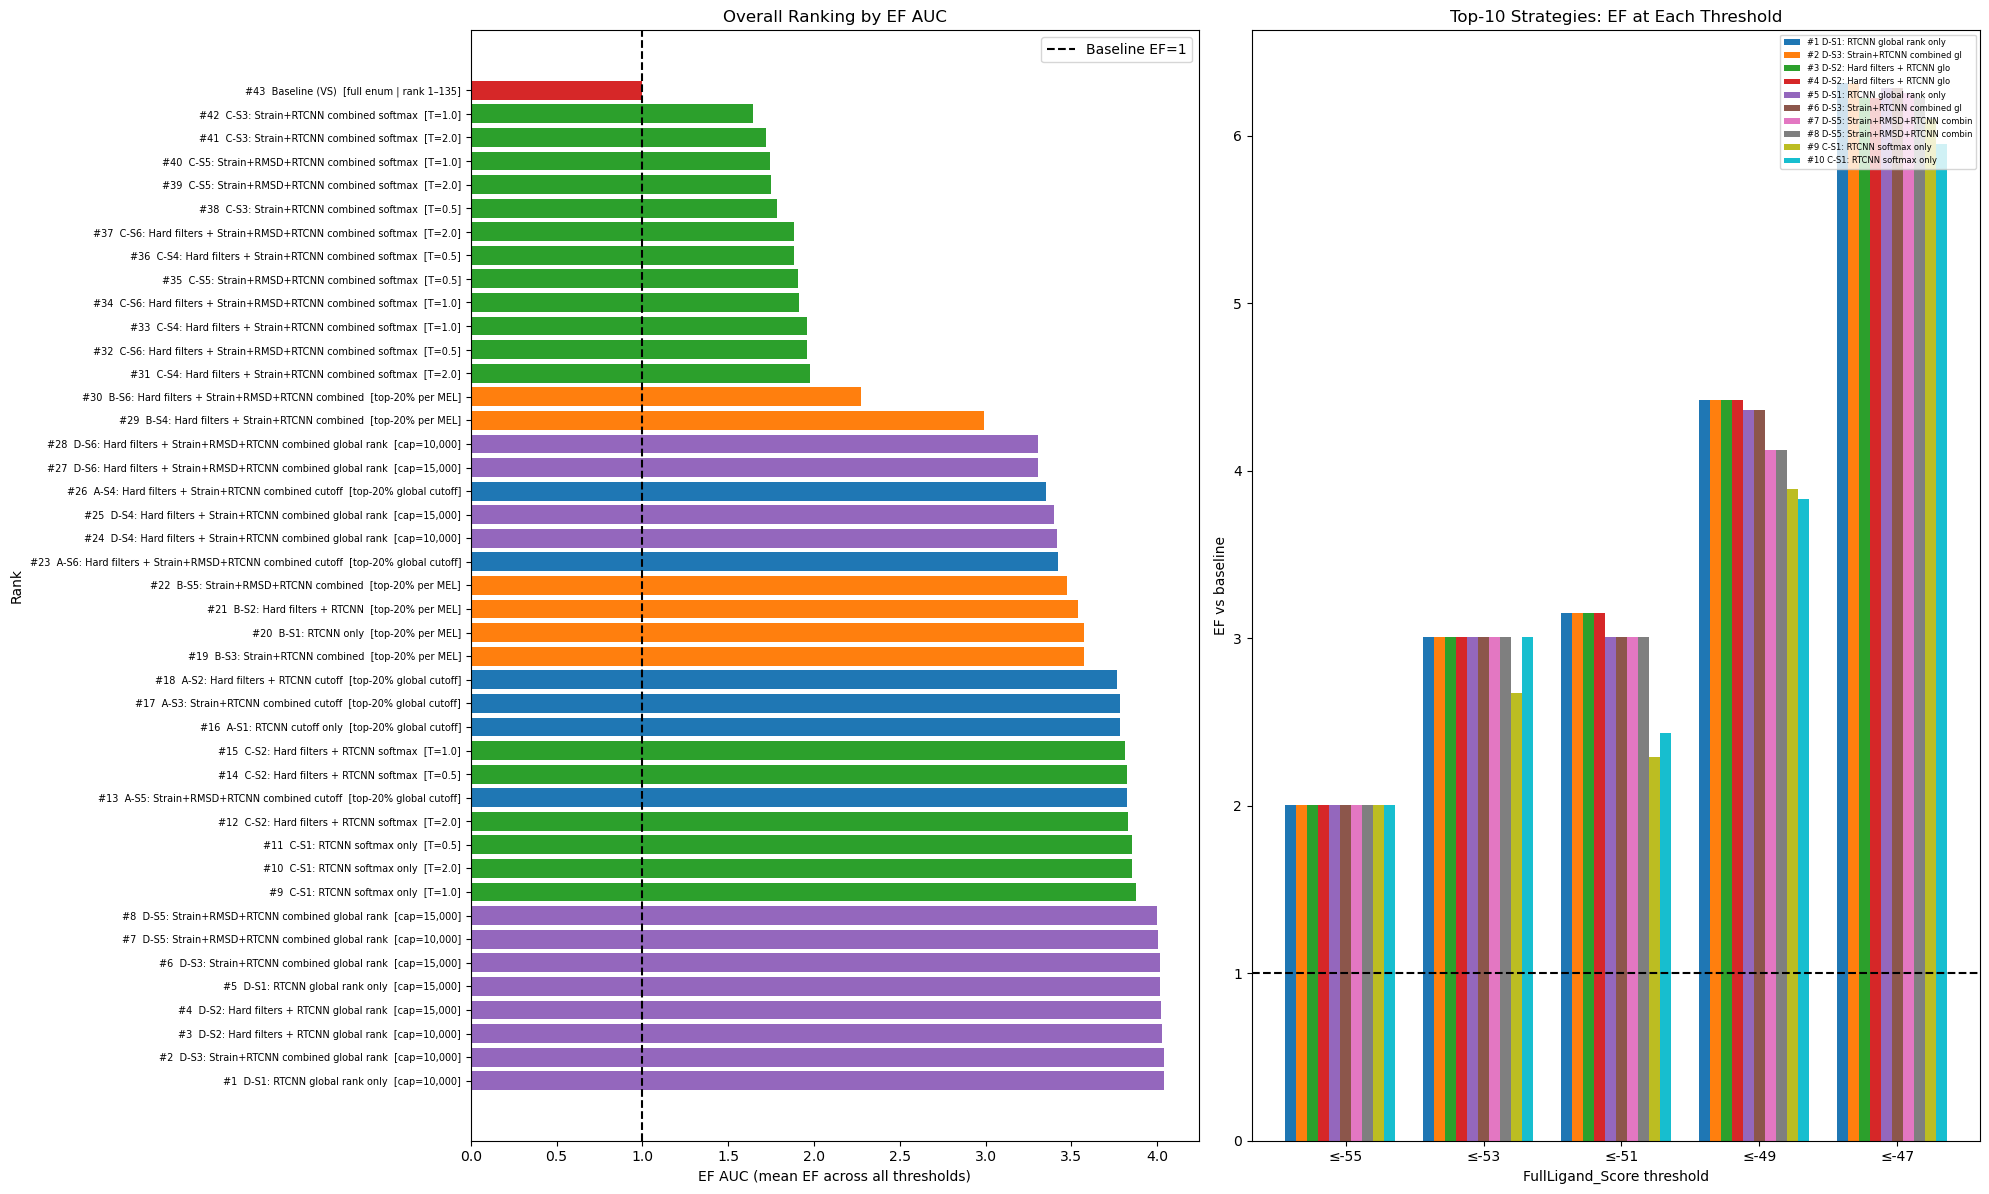


=== Absolute hit counts at strictest threshold (≤ -55) ===
                                              strategy_name                 config  n_mels  hits@-55  ef_auc
1                              D-S1: RTCNN global rank only             cap=10,000     486         2   4.041
21                               B-S2: Hard filters + RTCNN        top-20% per MEL     308         2   3.538
23   A-S6: Hard filters + Strain+RMSD+RTCNN combined cutoff  top-20% global cutoff     307         2   3.422
24   D-S4: Hard filters + Strain+RTCNN combined global rank             cap=10,000     477         2   3.415
25   D-S4: Hard filters + Strain+RTCNN combined global rank             cap=15,000     476         2   3.397
26        A-S4: Hard filters + Strain+RTCNN combined cutoff  top-20% global cutoff     319         2   3.351
29               B-S4: Hard filters + Strain+RTCNN combined        top-20% per MEL     308         2   2.992
31       C-S4: Hard filters + Strain+RTCNN combined softmax         

In [56]:
# ── Cross-strategy comparison: find the best configuration ─────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════════════════════════════════════
# USER-CONFIGURABLE PARAMETERS — adjust these for each protein / run
# ═══════════════════════════════════════════════════════════════════════════

# Score range for the EF curve sweep (x-axis of EF plots)
# Set to cover the meaningful part of your FullLigand_Score distribution
SCORE_RANGE_MIN = -60   # left  end of sweep (most negative / strictest)
SCORE_RANGE_MAX = -40   # right end of sweep (least negative / loosest)

# Specific thresholds reported in the table and bar charts
# Pick values that correspond to meaningful hit rates for this target
EVAL_THRESHOLDS = [-55, -53, -51, -49, -47]

# ═══════════════════════════════════════════════════════════════════════════

thresholds = np.linspace(SCORE_RANGE_MIN, SCORE_RANGE_MAX, 200)
baseline_n = len(baseline_ligands)

def ef_at(selected_df, T):
    n   = len(selected_df)
    if n == 0: return np.nan
    rate_sel  = (selected_df["FullLigand_Score"] <= T).sum() / n
    rate_base = (baseline_ligands["FullLigand_Score"] <= T).sum() / baseline_n
    return rate_sel / rate_base if rate_base > 0 else np.nan

def hit_count_at(selected_df, T):
    return int((selected_df["FullLigand_Score"] <= T).sum())

def ef_auc(selected_df):
    """Mean EF across the full threshold sweep — single aggregate rank metric."""
    n = len(selected_df)
    if n == 0: return np.nan
    rates_sel  = np.array([(selected_df["FullLigand_Score"] <= t).sum() / n
                            for t in thresholds])
    rates_base = np.array([(baseline_ligands["FullLigand_Score"] <= t).sum() / baseline_n
                            for t in thresholds])
    valid = rates_base > 0
    return float(np.nanmean(rates_sel[valid] / rates_base[valid]))

# ── Collect all results ────────────────────────────────────────────────────

records = []

# Baseline
records.append({
    "strategy_name" : "Baseline (VS)",
    "config"        : f"full enum | rank 1–{baseline_df['mel_rank'].max()}",
    "n_mels"        : len(baseline_df),
    "rank_max"      : int(baseline_df["mel_rank"].max()),
    "n_ligands"     : baseline_n,
    "ef_auc"        : 1.0,
    **{f"ef@{T}"    : 1.0             for T in EVAL_THRESHOLDS},
    **{f"hits@{T}"  : hit_count_at(baseline_ligands, T) for T in EVAL_THRESHOLDS},
})

# Strategy A (hard score cutoff — global top-X%)
if "results_a" in dir() and results_a:
    for s, r in results_a.items():
        sel = r["selected"]
        records.append({
            "strategy_name" : f"A-S{s}: {strategy_labels_a[s]}",
            "config"        : f"top-{int(GLOBAL_TOP*100)}% global cutoff",
            "n_mels"        : r["n_mels"],
            "rank_max"      : r["rank_max"],
            "n_ligands"     : r["n_ligands"],
            "ef_auc"        : ef_auc(sel),
            **{f"ef@{T}"   : ef_at(sel, T)        for T in EVAL_THRESHOLDS},
            **{f"hits@{T}" : hit_count_at(sel, T) for T in EVAL_THRESHOLDS},
        })

# Strategy B (greedy top-X% per MEL)
if "results_b" in dir() and results_b:
    for s, r in results_b.items():
        sel = r["selected"]
        records.append({
            "strategy_name" : f"B-S{s}: {strategy_labels_b[s]}",
            "config"        : f"top-{int(FRACTION*100)}% per MEL",
            "n_mels"        : r["n_mels"],
            "rank_max"      : r["rank_max"],
            "n_ligands"     : r["n_ligands"],
            "ef_auc"        : ef_auc(sel),
            **{f"ef@{T}"   : ef_at(sel, T)        for T in EVAL_THRESHOLDS},
            **{f"hits@{T}" : hit_count_at(sel, T) for T in EVAL_THRESHOLDS},
        })

# Strategy C (softmax sampling)
if "results_c" in dir() and results_c:
    for (s, temp), r in results_c.items():
        sel = r["selected"]
        records.append({
            "strategy_name" : f"C-S{s}: {strategy_labels_c[s]}",
            "config"        : f"T={temp}",
            "n_mels"        : r["n_mels"],
            "rank_max"      : r["rank_max"],
            "n_ligands"     : r["n_ligands"],
            "ef_auc"        : ef_auc(sel),
            **{f"ef@{T}"   : ef_at(sel, T)        for T in EVAL_THRESHOLDS},
            **{f"hits@{T}" : hit_count_at(sel, T) for T in EVAL_THRESHOLDS},
        })

# Strategy D (global rank + per-MEL cap)
if "results_d" in dir() and results_d:
    for (s, cap), r in results_d.items():
        sel = r["selected"]
        records.append({
            "strategy_name" : f"D-S{s}: {strategy_labels_d[s]}",
            "config"        : f"cap={cap:,}",
            "n_mels"        : r["n_mels"],
            "rank_max"      : r["rank_max"],
            "n_ligands"     : r["n_ligands"],
            "ef_auc"        : ef_auc(sel),
            **{f"ef@{T}"   : ef_at(sel, T)        for T in EVAL_THRESHOLDS},
            **{f"hits@{T}" : hit_count_at(sel, T) for T in EVAL_THRESHOLDS},
        })

df_cmp = pd.DataFrame(records).sort_values("ef_auc", ascending=False).reset_index(drop=True)
df_cmp.index += 1   # rank from 1

# ── Print ranked table ─────────────────────────────────────────────────────

ef_cols   = [f"ef@{T}"   for T in EVAL_THRESHOLDS]
hit_cols  = [f"hits@{T}" for T in EVAL_THRESHOLDS]
show_cols = ["strategy_name", "config", "n_mels", "rank_max", "n_ligands", "ef_auc"] + ef_cols

print("=== Strategy Ranking (sorted by EF AUC — mean EF across all thresholds) ===\n")
print(f"EF sweep range : {SCORE_RANGE_MIN} to {SCORE_RANGE_MAX}")
print(f"Hit thresholds : {EVAL_THRESHOLDS}\n")
pd.set_option("display.max_colwidth", 50)
pd.set_option("display.float_format", "{:.3f}".format)
print(df_cmp[show_cols].to_string())
print()
print(f"Winner: #{1}  {df_cmp.iloc[0]['strategy_name']}  [{df_cmp.iloc[0]['config']}]")
print(f"  EF AUC = {df_cmp.iloc[0]['ef_auc']:.3f}  |  ", end="")
for T in EVAL_THRESHOLDS:
    print(f"EF@{T} = {df_cmp.iloc[0][f'ef@{T}']:.3f}  hits = {df_cmp.iloc[0][f'hits@{T}']:.0f}", end="  |  ")
print()

# ── Bar chart: EF AUC for all configurations ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(20, max(6, len(df_cmp) * 0.28)))

# Left: EF AUC
colors = ["#d62728" if "Baseline" in n else
          "#1f77b4" if n.startswith("A-") else
          "#ff7f0e" if n.startswith("B-") else
          "#2ca02c" if n.startswith("C-") else
          "#9467bd" for n in df_cmp["strategy_name"]]

axes[0].barh(df_cmp.index[::-1], df_cmp["ef_auc"].iloc[::-1], color=colors[::-1])
axes[0].axvline(1.0, color="k", linestyle="--", linewidth=1.5, label="Baseline EF=1")
axes[0].set_xlabel("EF AUC (mean EF across all thresholds)")
axes[0].set_ylabel("Rank")
axes[0].set_yticks(df_cmp.index[::-1])
axes[0].set_yticklabels(
    [f"#{i}  {n}  [{c}]"
     for i, n, c in zip(df_cmp.index[::-1],
                         df_cmp["strategy_name"].iloc[::-1],
                         df_cmp["config"].iloc[::-1])],
    fontsize=7
)
axes[0].set_title("Overall Ranking by EF AUC")
axes[0].legend()

# Right: EF at each threshold as a heatmap-style bar group
x     = np.arange(len(EVAL_THRESHOLDS))
bar_w = 0.8 / min(len(df_cmp), 10)
top10 = df_cmp.head(10)

for i, (_, row) in enumerate(top10.iterrows()):
    vals = [row[f"ef@{T}"] for T in EVAL_THRESHOLDS]
    axes[1].bar(x + i * bar_w - 0.4, vals, width=bar_w,
                label=f"#{i+1} {row['strategy_name'][:30]}")

axes[1].axhline(1.0, color="k", linestyle="--", linewidth=1.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"≤{T}" for T in EVAL_THRESHOLDS])
axes[1].set_xlabel("FullLigand_Score threshold")
axes[1].set_ylabel("EF vs baseline")
axes[1].set_title("Top-10 Strategies: EF at Each Threshold")
axes[1].legend(fontsize=6, loc="upper right")

plt.tight_layout()
plt.show()

# ── Hit count comparison at most selective threshold ──────────────────────

T_strict = min(EVAL_THRESHOLDS)
print(f"\n=== Absolute hit counts at strictest threshold (≤ {T_strict}) ===")
hit_col = f"hits@{T_strict}"
print(df_cmp[["strategy_name", "config", "n_mels", hit_col, "ef_auc"]]
      .sort_values(hit_col, ascending=False)
      .head(15)
      .to_string())


#### [Skip] Intuition Test: Does picking the better synthons within a MEL actually give you better EF

=== Synthon Quality Ablation — Fixed 20% Slice, Vary Which 20% ===
Control: same MEL walk order (rank 1→N), same fraction (20%), only slice band changes
Hard filters applied in all conditions: Strain ≤ 15, CoreRMSD ≤ 2.0 Å
Baseline (VS) : 78 MELs, rank 1–135, 1,001,617 ligands

A: top 0–20%  (best)         | 308 MELs | rank 1–498 | 1,000,000 ligands
B: next 20–40%               | 308 MELs | rank 1–498 | 1,000,000 ligands
C: mid  40–60%               | 308 MELs | rank 1–498 | 1,000,000 ligands
D: low  60–80%               | 308 MELs | rank 1–498 | 1,000,000 ligands
E: worst 80–100%             | 308 MELs | rank 1–498 | 1,000,000 ligands


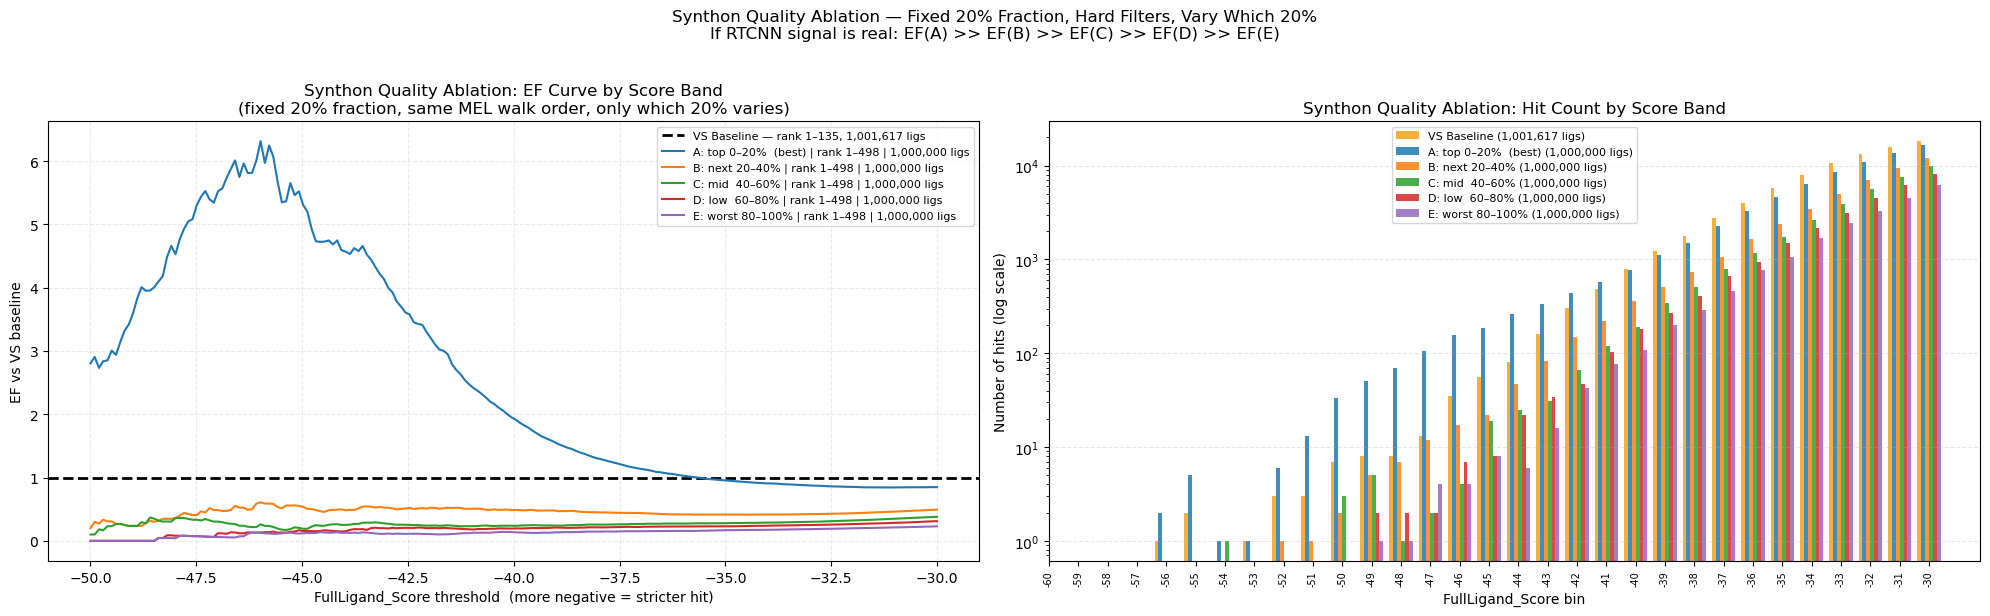


=== EF at Key Thresholds ===
Condition                        MELs  rank_max     n_ligs  EF@-38  EF@-40  EF@-42  EF@-44  EF@-46
VS Baseline                        78       135    1001617    1.000    1.000    1.000    1.000    1.000
A: top 0–20%  (best)              308       498    1000000    1.303    1.933    3.240    4.584    6.227
B: next 20–40%                    308       498    1000000    0.450    0.490    0.521    0.490    0.610
C: mid  40–60%                    308       498    1000000    0.256    0.239    0.240    0.256    0.261
D: low  60–80%                    308       498    1000000    0.213    0.195    0.203    0.154    0.131
E: worst 80–100%                  308       498    1000000    0.147    0.137    0.106    0.132    0.131

Interpretation guide:
  EF(A) >> EF(E) → RTCNN score is a real signal for FullLigand_Score
  EF(A) ≈ EF(E)  → RTCNN score has no predictive value
  MEL rank_max same across all → MEL coverage is identical (controlled)


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Parameters ─────────────────────────────────────────────────────────────
BUDGET     = 1_000_000
thresholds = np.linspace(-50, -30, 200)
EVAL_T     = [-38, -40, -42, -44, -46]

# ── Conditions: fixed 20% slice size, vary which 20% ───────────────────────
# Each condition takes exactly the [lo, hi) percentile band of each MEL's
# synthons sorted by RTCNN_Score ascending (best = most negative = first).
# Everything else is identical: same MEL walk order, same fraction size.
CONDITIONS = {
    "A: top 0–20%  (best)": (0.00, 0.20),
    "B: next 20–40%":       (0.20, 0.40),
    "C: mid  40–60%":       (0.40, 0.60),
    "D: low  60–80%":       (0.60, 0.80),
    "E: worst 80–100%":     (0.80, 1.00),
}
colors = {
    "A: top 0–20%  (best)": "tab:blue",
    "B: next 20–40%":       "tab:orange",
    "C: mid  40–60%":       "tab:green",
    "D: low  60–80%":       "tab:red",
    "E: worst 80–100%":     "tab:purple",
}

# ── Helpers ─────────────────────────────────────────────────────────────────
def hard_filter(df):
    return df[(df["Strain"] <= 15) & (df["CoreRmsd"] <= 2.0)].copy()

def run_slice_experiment(synthon_df, mel_ranked, lo, hi, budget):
    """
    Hard filter → sort each MEL's synthons by RTCNN_Score ascending (best first)
    → take the [lo, hi) percentile band → walk MELs in rank order until budget.
    """
    df = hard_filter(synthon_df)
    # Sort within each MEL group so iloc slicing gives the correct band
    mel_groups = {k: g.sort_values("RTCNN_Score", ascending=True)
                  for k, g in df.groupby("key_norm")}
    available_keys = set(mel_groups.keys())

    selected_parts, cumulative, n_mels = [], 0, 0
    rank_min = rank_max = None

    for _, row in mel_ranked.iterrows():
        if cumulative >= budget:
            break
        key = row["key_norm"]
        if key not in available_keys:
            continue

        mel_df  = mel_groups[key]
        n_total = len(mel_df)

        # Compute integer slice boundaries for this MEL
        idx_lo = int(np.floor(n_total * lo))
        idx_hi = int(np.ceil(n_total * hi))
        idx_hi = min(idx_hi, n_total)
        band   = mel_df.iloc[idx_lo:idx_hi]

        if len(band) == 0:
            continue

        n_take = min(len(band), budget - cumulative)
        selected_parts.append(band.iloc[:n_take])
        cumulative += n_take
        n_mels += 1

        if rank_min is None:
            rank_min = row["mel_rank"]
        rank_max = row["mel_rank"]

    selected = pd.concat(selected_parts, ignore_index=True) if selected_parts else pd.DataFrame()
    return selected, n_mels, len(selected), rank_min, rank_max

def compute_ef(sel, base, thresholds):
    n_sel, n_base = len(sel), len(base)
    ef = []
    for t in thresholds:
        r_sel  = (sel["FullLigand_Score"]  <= t).sum() / n_sel  if n_sel  > 0 else 0
        r_base = (base["FullLigand_Score"] <= t).sum() / n_base if n_base > 0 else 0
        ef.append(r_sel / r_base if r_base > 0 else np.nan)
    return np.array(ef)

def count_per_bin(df, bins):
    return np.array(
        [((df["FullLigand_Score"] >= b) & (df["FullLigand_Score"] < b + 1)).sum()
         for b in bins], dtype=float)

# ── Run all conditions ──────────────────────────────────────────────────────
print("=== Synthon Quality Ablation — Fixed 20% Slice, Vary Which 20% ===")
print("Control: same MEL walk order (rank 1→N), same fraction (20%), only slice band changes")
print(f"Hard filters applied in all conditions: Strain ≤ 15, CoreRMSD ≤ 2.0 Å")
print(f"Baseline (VS) : {len(baseline_df)} MELs, "
      f"rank {baseline_df['mel_rank'].min()}–{baseline_df['mel_rank'].max()}, "
      f"{len(baseline_ligands):,} ligands\n")

results = {}
for label, (lo, hi) in CONDITIONS.items():
    sel, n_mels, n_ligs, r_min, r_max = run_slice_experiment(
        synthon_ground_truth, mel_ranked, lo, hi, BUDGET)
    results[label] = dict(selected=sel, n_mels=n_mels, n_ligands=n_ligs,
                          rank_min=r_min, rank_max=r_max,
                          ef=compute_ef(sel, baseline_ligands, thresholds))
    print(f"{label:<28} | {n_mels} MELs | rank {r_min}–{r_max} | {n_ligs:,} ligands")

# ── Plot ────────────────────────────────────────────────────────────────────
score_bins = np.arange(-60, -29, 1)
x          = np.arange(len(score_bins))
n_bars     = 1 + len(CONDITIONS)
bar_w      = 0.8 / n_bars
# center baseline + conditions as a group
baseline_offset = -(n_bars - 1) / 2 * bar_w
cond_offsets    = {label: (-(n_bars - 1) / 2 + 1 + i) * bar_w
                   for i, label in enumerate(CONDITIONS)}

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Left: EF curves
ax = axes[0]
ax.axhline(1.0, color="k", linewidth=2, linestyle="--",
           label=f"VS Baseline — rank 1–{baseline_df['mel_rank'].max()}, "
                 f"{len(baseline_ligands):,} ligs")
for label in CONDITIONS:
    r = results[label]
    ax.plot(thresholds, r["ef"], color=colors[label],
            label=f"{label} | rank 1–{r['rank_max']} | {r['n_ligands']:,} ligs")
ax.set_xlabel("FullLigand_Score threshold  (more negative = stricter hit)")
ax.set_ylabel("EF vs VS baseline")
ax.set_title("Synthon Quality Ablation: EF Curve by Score Band\n"
             "(fixed 20% fraction, same MEL walk order, only which 20% varies)")
ax.legend(fontsize=8)
ax.grid(alpha=0.25, linestyle="--")

# Right: hit count histogram
ax = axes[1]
baseline_counts = count_per_bin(baseline_ligands, score_bins)
ax.bar(x + baseline_offset,
       np.where(baseline_counts == 0, np.nan, baseline_counts),
       bar_w, color="#F5A623", alpha=0.9,
       label=f"VS Baseline ({len(baseline_ligands):,} ligs)")
for label in CONDITIONS:
    counts = count_per_bin(results[label]["selected"], score_bins)
    ax.bar(x + cond_offsets[label],
           np.where(counts == 0, np.nan, counts),
           bar_w, color=colors[label], alpha=0.85,
           label=f"{label} ({results[label]['n_ligands']:,} ligs)")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([str(b) for b in score_bins], rotation=90, fontsize=7)
ax.set_xlabel("FullLigand_Score bin")
ax.set_ylabel("Number of hits (log scale)")
ax.set_title("Synthon Quality Ablation: Hit Count by Score Band")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3, linestyle="--")

plt.suptitle(
    "Synthon Quality Ablation — Fixed 20% Fraction, Hard Filters, Vary Which 20%\n"
    "If RTCNN signal is real: EF(A) >> EF(B) >> EF(C) >> EF(D) >> EF(E)",
    fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# ── Summary table ───────────────────────────────────────────────────────────
baseline_n = len(baseline_ligands)
print("\n=== EF at Key Thresholds ===")
header = f"{'Condition':<30} {'MELs':>6} {'rank_max':>9} {'n_ligs':>10}"
for T in EVAL_T:
    header += f"  EF@{T}"
print(header)

# Baseline row
row = f"{'VS Baseline':<30} {len(baseline_df):>6} {int(baseline_df['mel_rank'].max()):>9} {baseline_n:>10}"
for T in EVAL_T:
    row += f"  {'1.000':>7}"
print(row)

for label in CONDITIONS:
    r, sel = results[label], results[label]["selected"]
    n = len(sel)
    row = f"{label:<30} {r['n_mels']:>6} {r['rank_max']:>9} {r['n_ligands']:>10}"
    for T in EVAL_T:
        rate_sel  = (sel["FullLigand_Score"] <= T).sum() / n if n > 0 else 0
        rate_base = (baseline_ligands["FullLigand_Score"] <= T).sum() / baseline_n
        ef_val    = rate_sel / rate_base if rate_base > 0 else float("nan")
        row += f"  {ef_val:>7.3f}"
    print(row)

print("\nInterpretation guide:")
print("  EF(A) >> EF(E) → RTCNN score is a real signal for FullLigand_Score")
print("  EF(A) ≈ EF(E)  → RTCNN score has no predictive value")
print("  MEL rank_max same across all → MEL coverage is identical (controlled)")


### ICM ScreenReplace Result - Strategy Selected: Strategy C, T = 1, RTCNN Softmax Only

VS baseline            : 974,233 ligands
SmartEnum ScreenReplace: 909,285 ligands
Random 1M              : 934,051 ligands

Computing EF curves...
  [VS] EF100: first valid point already has n_active=478.0 (random had 0 hits at stricter thresholds). Reporting raw EF at threshold -41.58.
  [SmartEnum] EF100: first valid point already has n_active=1638.0 (random had 0 hits at stricter thresholds). Reporting raw EF at threshold -41.58.
  [SmartEnum] EF1000: first valid point already has n_active=1638.0 (random had 0 hits at stricter thresholds). Reporting raw EF at threshold -41.58.

VS  baseline     : EF100  = 478.0×  at threshold -41.58
VS  baseline     : EF1000 = 151.2×  at threshold -40.27
SmartEnum SR     : EF100  = 1638.0×  at threshold -41.58
SmartEnum SR     : EF1000 = 1638.0×  at threshold -41.58


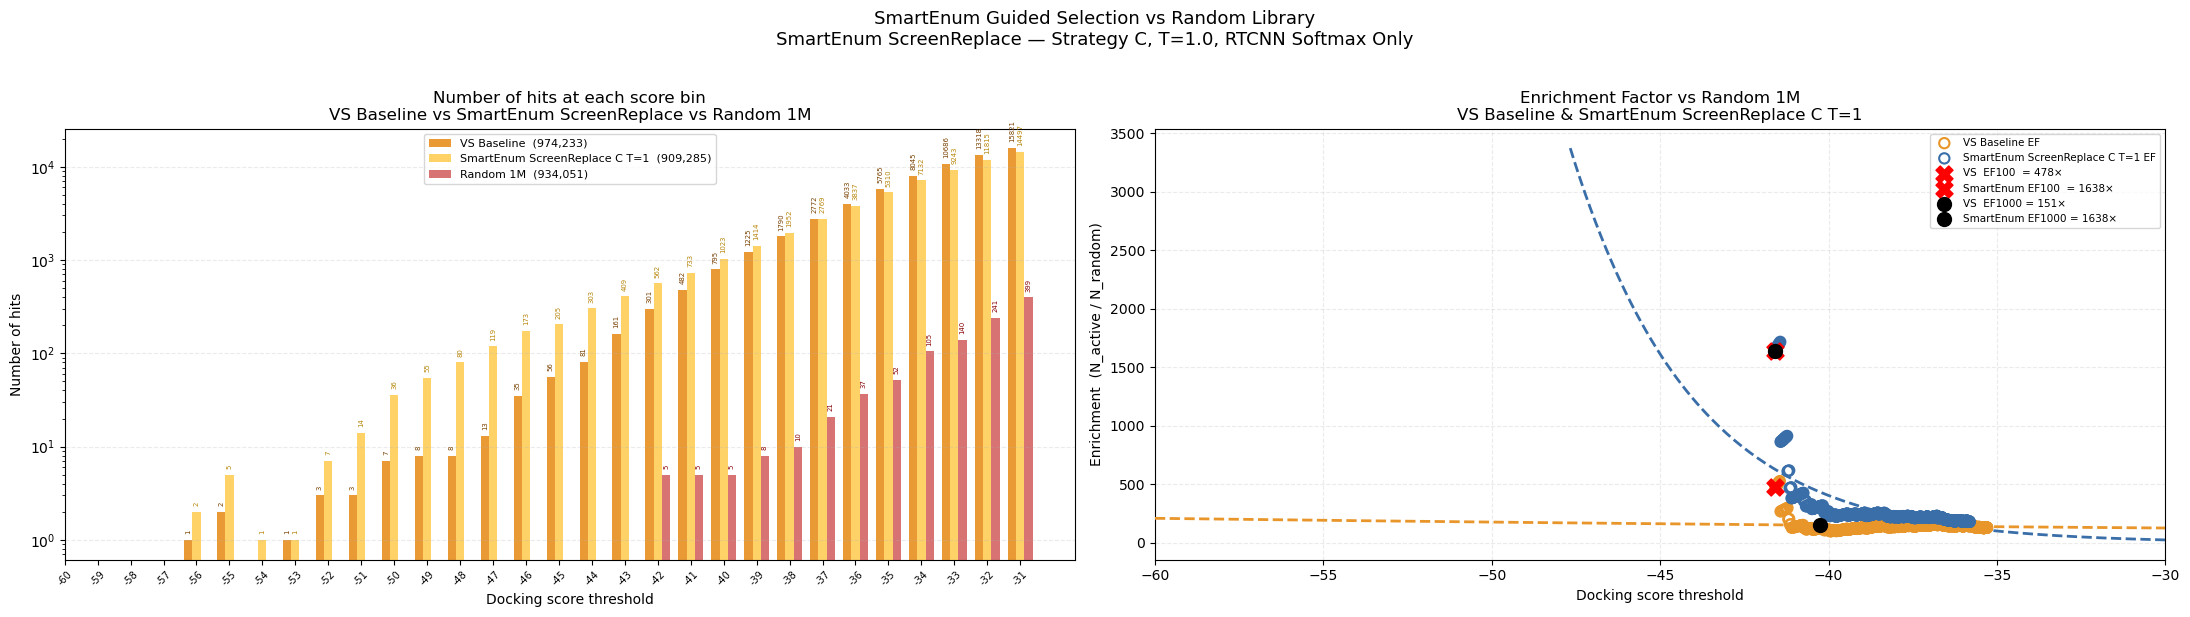

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ═══════════════════════════════════════════════════════════════════════════
# USER-CONFIGURABLE
# ═══════════════════════════════════════════════════════════════════════════
SCORE_MIN  = -60   # left  end — must cover the full score range of your data
SCORE_MAX  = -30   # right end
MAX_ACTIVE = 10500 # stop EF walk after this many actives

# ═══════════════════════════════════════════════════════════════════════════
# DATASET SETUP
# ═══════════════════════════════════════════════════════════════════════════
vs_scores    = baseline_ligands["FullLigand_Score"].dropna().values
smart_scores = results_c[(1, 1.0)]["selected"]["FullLigand_Score"].dropna().values
rand_scores  = random1M_docked["Score"].dropna().values

vs_sorted    = np.sort(vs_scores)
smart_sorted = np.sort(smart_scores)

n_vs    = len(vs_sorted)
n_smart = len(smart_sorted)
n_rand  = len(rand_scores)

print(f"VS baseline            : {n_vs:,} ligands")
print(f"SmartEnum ScreenReplace: {n_smart:,} ligands")
print(f"Random 1M              : {n_rand:,} ligands")

# ═══════════════════════════════════════════════════════════════════════════
# HIT COUNT PER SCORE BIN
# ═══════════════════════════════════════════════════════════════════════════
score_bins = np.arange(SCORE_MIN, SCORE_MAX, 1)

def bin_counts(scores, bins):
    return np.array([((scores >= b) & (scores < b + 1)).sum()
                     for b in bins], dtype=float)

vs_bins    = bin_counts(vs_scores,    score_bins)
smart_bins = bin_counts(smart_scores, score_bins)
rand_bins  = bin_counts(rand_scores,  score_bins)

# ═══════════════════════════════════════════════════════════════════════════
# EF CURVE COMPUTATION
# Walk down ranked actives; at rank i:
#   threshold = score of i-th active (most negative first)
#   N_active  = i + 1
#   N_decoy   = # random compounds with score <= threshold
#   EF        = N_active / N_decoy   (skip if N_decoy == 0)
# ═══════════════════════════════════════════════════════════════════════════
def compute_ef_curve(active_sorted, random_scores, max_active=MAX_ACTIVE):
    records = []
    for i in range(min(max_active, len(active_sorted))):
        threshold = active_sorted[i]
        if threshold == 0:
            continue
        n_active = i + 1
        n_decoy  = (random_scores <= threshold).sum()
        if n_decoy == 0:
            continue
        records.append({"threshold": threshold,
                         "n_active":  n_active,
                         "n_decoy":   n_decoy,
                         "ef":        n_active / n_decoy})
    return pd.DataFrame(records)

print("\nComputing EF curves...")
df_vs_ef    = compute_ef_curve(vs_sorted,    rand_scores)
df_smart_ef = compute_ef_curve(smart_sorted, rand_scores)

# ═══════════════════════════════════════════════════════════════════════════
# EXPONENTIAL FIT: EF(x) = a * exp(b * x)
# Fitted only on stable region where n_active > 50
# ═══════════════════════════════════════════════════════════════════════════
def exp_func(x, a, b):
    return a * np.exp(b * x)

def fit_ef_curve(df_ef):
    fit_df = df_ef[(df_ef["n_active"] > 50) & np.isfinite(df_ef["ef"])].copy()
    if len(fit_df) < 2:
        return None
    try:
        popt, _ = curve_fit(exp_func, fit_df["threshold"], fit_df["ef"],
                            p0=[1e6, 0.3], maxfev=10000)
        return popt
    except Exception:
        return None

vs_popt    = fit_ef_curve(df_vs_ef)
smart_popt = fit_ef_curve(df_smart_ef)

# ═══════════════════════════════════════════════════════════════════════════
# EF100 / EF1000 EXTRACTION
# ═══════════════════════════════════════════════════════════════════════════
def get_ef_at_n(df_ef, popt, n_hits, label=""):
    row = df_ef[df_ef["n_active"] >= n_hits]
    if len(row) == 0:
        return None, None
    first_n = row.iloc[0]["n_active"]
    t       = row.iloc[0]["threshold"]
    if first_n > n_hits:
        print(f"  [{label}] EF{n_hits}: first valid point already has "
              f"n_active={first_n} (random had 0 hits at stricter thresholds). "
              f"Reporting raw EF at threshold {t:.2f}.")
        return t, row.iloc[0]["ef"]
    ef = exp_func(t, *popt) if popt is not None else row.iloc[0]["ef"]
    return t, ef

vs_t100,    vs_ef100    = get_ef_at_n(df_vs_ef,    vs_popt,    100,  "VS")
vs_t1000,   vs_ef1000   = get_ef_at_n(df_vs_ef,    vs_popt,    1000, "VS")
sm_t100,    sm_ef100    = get_ef_at_n(df_smart_ef, smart_popt, 100,  "SmartEnum")
sm_t1000,   sm_ef1000   = get_ef_at_n(df_smart_ef, smart_popt, 1000, "SmartEnum")

print(f"\nVS  baseline     : EF100  = {vs_ef100:.1f}×  at threshold {vs_t100:.2f}")
print(f"VS  baseline     : EF1000 = {vs_ef1000:.1f}×  at threshold {vs_t1000:.2f}")
print(f"SmartEnum SR     : EF100  = {sm_ef100:.1f}×  at threshold {sm_t100:.2f}")
print(f"SmartEnum SR     : EF1000 = {sm_ef1000:.1f}×  at threshold {sm_t1000:.2f}")

# ═══════════════════════════════════════════════════════════════════════════
# PLOT
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(22, 6))

# ── Left: hit-count bar chart (log scale) ────────────────────────────────────
ax    = axes[0]
x     = np.arange(len(score_bins))
bar_w = 0.25

bars_vs    = ax.bar(x - bar_w, np.where(vs_bins    == 0, np.nan, vs_bins),
                    bar_w, color="#E8952A", alpha=0.95,
                    label=f"VS Baseline  ({n_vs:,})")
bars_smart = ax.bar(x,         np.where(smart_bins == 0, np.nan, smart_bins),
                    bar_w, color="#FFD060", alpha=0.95,
                    label=f"SmartEnum ScreenReplace C T=1  ({n_smart:,})")
bars_rand  = ax.bar(x + bar_w, np.where(rand_bins  == 0, np.nan, rand_bins),
                    bar_w, color="#CC4444", alpha=0.75,
                    label=f"Random 1M  ({n_rand:,})")

for bars, counts, color in [(bars_vs,    vs_bins,    "#7A4000"),
                              (bars_smart, smart_bins, "#B8860B"),
                              (bars_rand,  rand_bins,  "#880000")]:
    for bar, count in zip(bars, counts):
        if count > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, count * 1.15,
                    str(int(count)), ha="center", va="bottom",
                    fontsize=5, color=color, rotation=90)

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([str(b) for b in score_bins], rotation=45, fontsize=7)
ax.set_xlabel("Docking score threshold")
ax.set_ylabel("Number of hits")
ax.set_title("Number of hits at each score bin\nVS Baseline vs SmartEnum ScreenReplace vs Random 1M")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.25, linestyle="--")

# ── Right: EF scatter + exponential fit + markers ────────────────────────────
ax = axes[1]

for df_ef, popt, sc_color, label in [
        (df_vs_ef,    vs_popt,    "#E8952A", "VS Baseline"),
        (df_smart_ef, smart_popt, "#3A6EA8", "SmartEnum ScreenReplace C T=1")]:

    sparse = df_ef.iloc[::10]   # every 10th point to reduce clutter
    ax.scatter(sparse["threshold"], sparse["ef"],
               s=55, facecolors="none", edgecolors=sc_color,
               linewidths=1.5, zorder=5, label=f"{label} EF")

    if popt is not None:
        x_fit = np.linspace(SCORE_MIN, SCORE_MAX, 400)
        y_fit = exp_func(x_fit, *popt)
        # Only plot fit where it's positive and within reasonable range
        mask = (y_fit > 0) & (y_fit < df_ef["ef"].max() * 2)
        ax.plot(x_fit[mask], y_fit[mask],
                color=sc_color, linewidth=2, linestyle="--", zorder=3)

# Red X = EF100, black circle = EF1000
for t, ef, marker, color, ms, lbl in [
        (vs_t100,  vs_ef100,  "X", "red",   150, f"VS  EF100  = {vs_ef100:.0f}×"),
        (sm_t100,  sm_ef100,  "X", "red",   150, f"SmartEnum EF100  = {sm_ef100:.0f}×"),
        (vs_t1000, vs_ef1000, "o", "black", 100, f"VS  EF1000 = {vs_ef1000:.0f}×"),
        (sm_t1000, sm_ef1000, "o", "black", 100, f"SmartEnum EF1000 = {sm_ef1000:.0f}×")]:
    if t is not None and ef is not None:
        ax.scatter([t], [ef], marker=marker, color=color,
                   s=ms, zorder=10, label=lbl)

ax.set_xlim(SCORE_MIN, SCORE_MAX)   # match left plot x-axis range
ax.set_xlabel("Docking score threshold")
ax.set_ylabel("Enrichment  (N_active / N_random)")
ax.set_title("Enrichment Factor vs Random 1M\nVS Baseline & SmartEnum ScreenReplace C T=1")
ax.legend(fontsize=7.5, loc="upper right")
ax.grid(alpha=0.25, linestyle="--")

plt.suptitle(
    "SmartEnum Guided Selection vs Random Library\n"
    "SmartEnum ScreenReplace — Strategy C, T=1.0, RTCNN Softmax Only",
    fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [66]:
smart_sorted = np.sort(results_c[(1, 1.0)]["selected"]["FullLigand_Score"].dropna().values)

print(f"SmartEnum SR — threshold at 100  actives : {smart_sorted[99]:.3f}")
print(f"SmartEnum SR — threshold at 1000 actives : {smart_sorted[999]:.3f}")

# Same for VS baseline for comparison
vs_sorted = np.sort(baseline_ligands["FullLigand_Score"].dropna().values)
print(f"\nVS Baseline  — threshold at 100  actives : {vs_sorted[99]:.3f}")
print(f"VS Baseline  — threshold at 1000 actives : {vs_sorted[999]:.3f}")


SmartEnum SR — threshold at 100  actives : -48.361
SmartEnum SR — threshold at 1000 actives : -43.003

VS Baseline  — threshold at 100  actives : -44.734
VS Baseline  — threshold at 1000 actives : -40.268


VS baseline            : 974,233 ligands
SmartEnum ScreenReplace: 909,285 ligands
Random 1M              : 934,051 ligands

VS  EF curve: 12 valid integer thresholds
SmartEnum EF curve: 12 valid integer thresholds

VS  baseline     : EF100  = 175.0×   threshold = -44.734
VS  baseline     : EF1000 = 143.4×  threshold = -40.268
SmartEnum SR     : EF100  = 1104.3×   threshold = -48.361
SmartEnum SR     : EF1000 = 489.6×  threshold = -43.003
  EF100 / EF1000 — How These Are Computed

EF curve is built at INTEGER thresholds (-60 to -30):
  At each threshold t:  EF(t) = N_active(t) / N_random(t). Only valid where N_random(t) > 0.
An exponential model  EF(t) = a * exp(b * t)  is fitted to the valid region (where random has hits).

EF100 / EF1000 cannot be read directly from the scatter because at the strict thresholds where the top-100 or top-1000 actives live, the random set has ZERO hits 
— EF is undefined there.

So instead:
  1) Find the exact score of the 100th best active  → threshold_1

/Users/liuwenjin/miniforge3/envs/openvs005/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


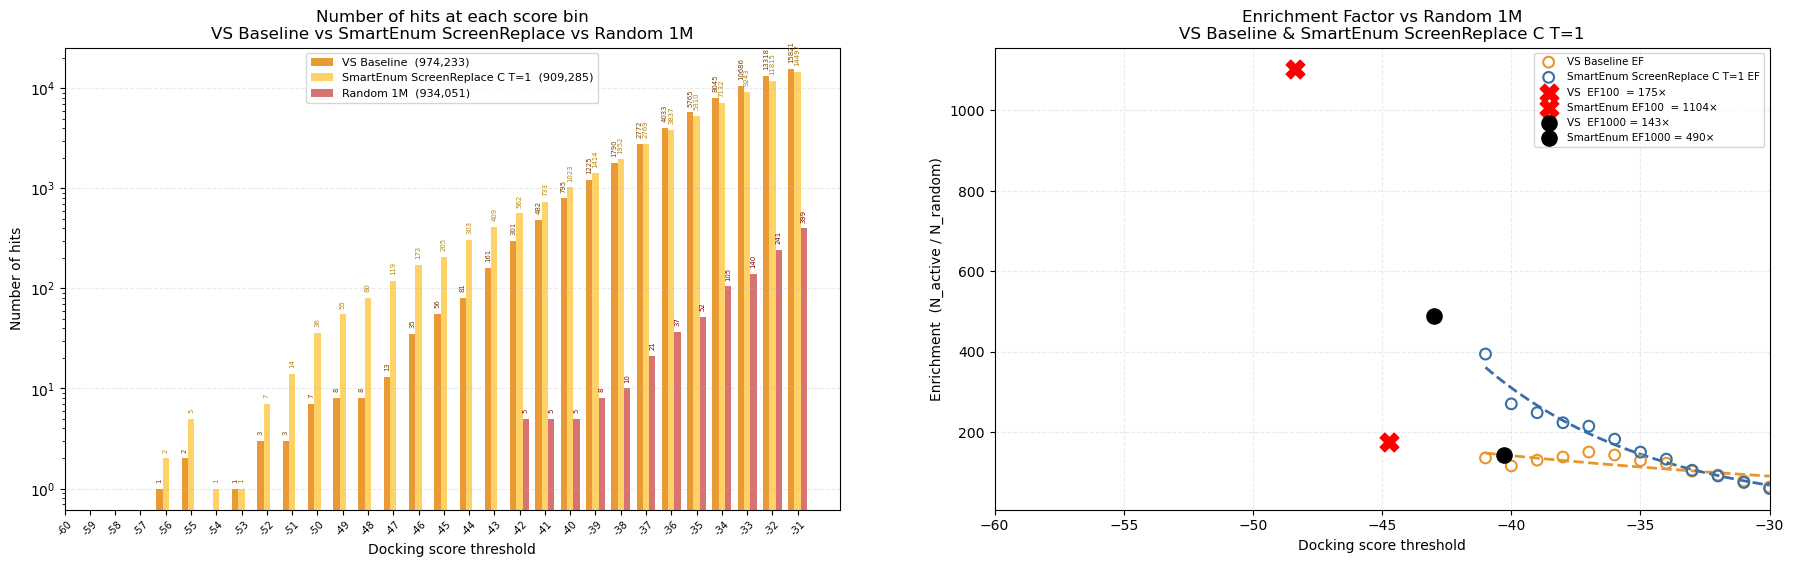

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ═══════════════════════════════════════════════════════════════════════════
# USER-CONFIGURABLE
# ═══════════════════════════════════════════════════════════════════════════
SCORE_MIN = -60
SCORE_MAX = -30

# ═══════════════════════════════════════════════════════════════════════════
# DATASET
# ═══════════════════════════════════════════════════════════════════════════
vs_scores    = baseline_ligands["FullLigand_Score"].dropna().values
smart_scores = results_c[(1, 1.0)]["selected"]["FullLigand_Score"].dropna().values
rand_scores  = random1M_docked["Score"].dropna().values

vs_sorted    = np.sort(vs_scores)
smart_sorted = np.sort(smart_scores)
n_vs    = len(vs_sorted)
n_smart = len(smart_sorted)
n_rand  = len(rand_scores)

print(f"VS baseline            : {n_vs:,} ligands")
print(f"SmartEnum ScreenReplace: {n_smart:,} ligands")
print(f"Random 1M              : {n_rand:,} ligands")

# ═══════════════════════════════════════════════════════════════════════════
# HIT COUNT PER SCORE BIN (bar chart)
# ═══════════════════════════════════════════════════════════════════════════
score_bins = np.arange(SCORE_MIN, SCORE_MAX, 1)

def bin_counts(scores, bins):
    return np.array([((scores >= b) & (scores < b + 1)).sum()
                     for b in bins], dtype=float)

vs_bins    = bin_counts(vs_scores,    score_bins)
smart_bins = bin_counts(smart_scores, score_bins)
rand_bins  = bin_counts(rand_scores,  score_bins)

# ═══════════════════════════════════════════════════════════════════════════
# EF CURVE — integer thresholds, only where N_decoy > 0
# At each integer threshold t:
#   N_active = # active compounds with score <= t  (cumulative)
#   N_decoy  = # random compounds with score <= t  (cumulative)
#   EF       = N_active / N_decoy   (only if N_decoy > 0)
# ═══════════════════════════════════════════════════════════════════════════
int_thresholds = np.arange(SCORE_MIN, SCORE_MAX + 1, 1)

def build_ef_df(active_scores, random_scores, thresholds):
    records = []
    for t in thresholds:
        n_active = (active_scores <= t).sum()
        n_decoy  = (random_scores <= t).sum()
        if n_decoy == 0 or n_active == 0:
            continue
        records.append({"threshold": t,
                         "n_active":  n_active,
                         "n_decoy":   n_decoy,
                         "ef":        n_active / n_decoy})
    return pd.DataFrame(records)

df_vs_ef    = build_ef_df(vs_scores,    rand_scores, int_thresholds)
df_smart_ef = build_ef_df(smart_scores, rand_scores, int_thresholds)

print(f"\nVS  EF curve: {len(df_vs_ef)} valid integer thresholds")
print(f"SmartEnum EF curve: {len(df_smart_ef)} valid integer thresholds")

# ═══════════════════════════════════════════════════════════════════════════
# EXPONENTIAL FIT: EF(t) = a * exp(b * t)
# ═══════════════════════════════════════════════════════════════════════════
def exp_func(x, a, b):
    return a * np.exp(b * x)

def fit_ef_curve(df_ef):
    df = df_ef[np.isfinite(df_ef["ef"])].copy()
    if len(df) < 2:
        return None
    try:
        popt, _ = curve_fit(exp_func, df["threshold"], df["ef"],
                            p0=[1e4, 0.3], maxfev=10000)
        return popt
    except Exception as e:
        print(f"  Fit failed: {e}")
        return None

vs_popt    = fit_ef_curve(df_vs_ef)
smart_popt = fit_ef_curve(df_smart_ef)

# ═══════════════════════════════════════════════════════════════════════════
# EF100 / EF1000 — find threshold from data, read EF from fitted model
# threshold for EF100  = active_sorted[99]   (score of 100th best active)
# threshold for EF1000 = active_sorted[999]
# plug into fitted curve to get EF value
# ═══════════════════════════════════════════════════════════════════════════
def get_ef_marker(active_sorted, popt, n):
    t  = active_sorted[n - 1]
    ef = exp_func(t, *popt) if popt is not None else np.nan
    return t, ef

vs_t100,    vs_ef100    = get_ef_marker(vs_sorted,    vs_popt,    100)
vs_t1000,   vs_ef1000   = get_ef_marker(vs_sorted,    vs_popt,    1000)
sm_t100,    sm_ef100    = get_ef_marker(smart_sorted,  smart_popt, 100)
sm_t1000,   sm_ef1000   = get_ef_marker(smart_sorted,  smart_popt, 1000)

print(f"\nVS  baseline     : EF100  = {vs_ef100:.1f}×   threshold = {vs_t100:.3f}")
print(f"VS  baseline     : EF1000 = {vs_ef1000:.1f}×  threshold = {vs_t1000:.3f}")
print(f"SmartEnum SR     : EF100  = {sm_ef100:.1f}×   threshold = {sm_t100:.3f}")
print(f"SmartEnum SR     : EF1000 = {sm_ef1000:.1f}×  threshold = {sm_t1000:.3f}")

# ═══════════════════════════════════════════════════════════════════════════
# PLOT
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(22, 6))

# ── Left: hit-count bar chart (log scale) ────────────────────────────────────
ax    = axes[0]
x     = np.arange(len(score_bins))
bar_w = 0.25

bars_vs    = ax.bar(x - bar_w, np.where(vs_bins    == 0, np.nan, vs_bins),
                    bar_w, color="#E8952A", alpha=0.95,
                    label=f"VS Baseline  ({n_vs:,})")
bars_smart = ax.bar(x,         np.where(smart_bins == 0, np.nan, smart_bins),
                    bar_w, color="#FFD060", alpha=0.95,
                    label=f"SmartEnum ScreenReplace C T=1  ({n_smart:,})")
bars_rand  = ax.bar(x + bar_w, np.where(rand_bins  == 0, np.nan, rand_bins),
                    bar_w, color="#CC4444", alpha=0.75,
                    label=f"Random 1M  ({n_rand:,})")

for bars, counts, color in [(bars_vs,    vs_bins,    "#7A4000"),
                              (bars_smart, smart_bins, "#B8860B"),
                              (bars_rand,  rand_bins,  "#880000")]:
    for bar, count in zip(bars, counts):
        if count > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, count * 1.15,
                    str(int(count)), ha="center", va="bottom",
                    fontsize=5, color=color, rotation=90)

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([str(b) for b in score_bins], rotation=45, fontsize=7)
ax.set_xlabel("Docking score threshold")
ax.set_ylabel("Number of hits")
ax.set_title("Number of hits at each score bin\nVS Baseline vs SmartEnum ScreenReplace vs Random 1M")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.25, linestyle="--")

# ── Right: EF scatter (integer thresholds) + exponential fit + markers ────────
ax = axes[1]

for df_ef, popt, sc_color, label in [
        (df_vs_ef,    vs_popt,    "#E8952A", "VS Baseline"),
        (df_smart_ef, smart_popt, "#3A6EA8", "SmartEnum ScreenReplace C T=1")]:

    ax.scatter(df_ef["threshold"], df_ef["ef"],
               s=60, facecolors="none", edgecolors=sc_color,
               linewidths=1.5, zorder=5, label=f"{label} EF")

    if popt is not None:
        x_fit = np.linspace(df_ef["threshold"].min(),
                            df_ef["threshold"].max(), 400)
        ax.plot(x_fit, exp_func(x_fit, *popt),
                color=sc_color, linewidth=2, linestyle="--", zorder=3)

# Red X = EF100, black circle = EF1000  (from fitted curve)
for t, ef, marker, color, ms, lbl in [
        (vs_t100,  vs_ef100,  "X", "red",   180, f"VS  EF100  = {vs_ef100:.0f}×"),
        (sm_t100,  sm_ef100,  "X", "red",   180, f"SmartEnum EF100  = {sm_ef100:.0f}×"),
        (vs_t1000, vs_ef1000, "o", "black", 120, f"VS  EF1000 = {vs_ef1000:.0f}×"),
        (sm_t1000, sm_ef1000, "o", "black", 120, f"SmartEnum EF1000 = {sm_ef1000:.0f}×")]:
    if t is not None and np.isfinite(ef):
        ax.scatter([t], [ef], marker=marker, color=color,
                   s=ms, zorder=10, label=lbl)

ax.set_xlim(SCORE_MIN, SCORE_MAX)
ax.set_xlabel("Docking score threshold")
ax.set_ylabel("Enrichment  (N_active / N_random)")
ax.set_title("Enrichment Factor vs Random 1M\nVS Baseline & SmartEnum ScreenReplace C T=1")
ax.legend(fontsize=7.5, loc="upper right")
ax.grid(alpha=0.25, linestyle="--")

print(f"  EF100 / EF1000 — How These Are Computed")
print(f"""
EF curve is built at INTEGER thresholds ({SCORE_MIN} to {SCORE_MAX}):
  At each threshold t:  EF(t) = N_active(t) / N_random(t). Only valid where N_random(t) > 0.
An exponential model  EF(t) = a * exp(b * t)  is fitted to the valid region (where random has hits).

EF100 / EF1000 cannot be read directly from the scatter because at the strict thresholds where the top-100 or top-1000 actives live, the random set has ZERO hits 
— EF is undefined there.

So instead:
  1) Find the exact score of the 100th best active  → threshold_100
  2) Find the exact score of the 1000th best active → threshold_1000
  3) Plug both into the fitted model to extrapolate EF: EF100  = a * exp(b * threshold_100) & EF1000 = a * exp(b * threshold_1000)
""")

print(f"  VS  baseline  | threshold_100  = {vs_t100:.3f} | EF100  = {vs_ef100:.1f}x  (from model)")
print(f"  VS  baseline  | threshold_1000 = {vs_t1000:.3f} | EF1000 = {vs_ef1000:.1f}x  (from model)")
print(f"  SmartEnum SR  | threshold_100  = {sm_t100:.3f} | EF100  = {sm_ef100:.1f}x  (from model, extrapolated — no random hits at this score)")
print(f"  SmartEnum SR  | threshold_1000 = {sm_t1000:.3f} | EF1000 = {sm_ef1000:.1f}x  (from model, extrapolated — no random hits at this score)")
print(f"\n  VS  fitted model : EF(t) = {vs_popt[0]:.2e} * exp({vs_popt[1]:.4f} * t)" if vs_popt is not None else "  VS  fit failed")
print(f"  SmartEnum fitted : EF(t) = {smart_popt[0]:.2e} * exp({smart_popt[1]:.4f} * t)" if smart_popt is not None else "  SmartEnum fit failed")
print(f"{'='*65}")

